# 1. Подготовка рабочей среды

На начальном этапе задаются параметры эксперимента, подключаются библиотеки и создается структура папок для промежуточных материалов, обученной модели и отчетных файлов. Единый порядок хранения файлов снижает риск путаницы при повторном запуске вычислений и упрощает перенос результатов в пользовательское приложение. Эксперимент строится с фиксированным начальным числом для случайных процедур для повторяемого разбиения отзывов на обучающую и проверочную части, а также для устойчивого сравнения качества модели при повторных запусках в Google Colab.

In [1]:
# Устанавливаем библиотеку для загрузки открытых наборов данных с площадки Hugging Face.
# Hugging Face — открытая площадка, где хранятся наборы данных и модели для задач обработки текста.
# Параметр -q уменьшает объем служебного вывода во время установки.

!pip install -q datasets

In [2]:
# Подключаем библиотеки, которые понадобятся на следующих этапах эксперимента.
# os отвечает за работу с папками и путями к файлам.
# json нужен для сохранения сведений о модели и метриках в текстовом формате.
# random управляет случайными операциями языка Python.
# numpy выполняет численные расчеты.
# pandas хранит таблицы с отзывами и результатами обработки.
# pathlib помогает задавать пути к файлам в удобной и надежной форме.

import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd


# Фиксируем начальное число для случайных процедур.
# Одинаковое значение помогает получать сопоставимые результаты при повторном запуске ячеек.

RANDOM_STATE = 42


# Передаем выбранное начальное число основным библиотекам.
# После фиксации случайных процедур разбиение данных и выбор строк будут воспроизводиться стабильнее.

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# Задаем корневую папку эксперимента.
# Все файлы будут размещаться внутри этой папки, чтобы материалы не смешивались
# со служебными файлами среды Google Colab.

PROJECT_DIR = Path("/content/irbis_feedback_experiment")


# Задаем папки для разных типов материалов.
# raw_data_dir предназначена для исходных загруженных материалов, если потребуется сохранить часть источника.
# processed_data_dir предназначена для очищенного набора отзывов.
# models_dir предназначена для сохранения обученной модели и служебных сведений о ней.
# reports_dir предназначена для таблиц качества и графиков проверки модели.

raw_data_dir = PROJECT_DIR / "data" / "raw"
processed_data_dir = PROJECT_DIR / "data" / "processed"
models_dir = PROJECT_DIR / "models"
reports_dir = PROJECT_DIR / "reports"


# Создаем папки, если они еще не существуют.
# exist_ok=True означает, что повторный запуск ячейки не вызовет ошибку,
# когда папка уже создана ранее.

for folder_path in [raw_data_dir, processed_data_dir, models_dir, reports_dir]:
    folder_path.mkdir(parents=True, exist_ok=True)


# Сохраняем основные параметры эксперимента в словарь.
# Словарь понадобится при обучении модели, оценке качества и сохранении сведений для приложения.

experiment_config = {
    "random_state": RANDOM_STATE,
    "project_dir": str(PROJECT_DIR),
    "raw_data_dir": str(raw_data_dir),
    "processed_data_dir": str(processed_data_dir),
    "models_dir": str(models_dir),
    "reports_dir": str(reports_dir),
}

In [3]:
# Проверяем, что структура папок создана корректно.
# В ячейке выводится только таблица с путями
folder_check = pd.DataFrame(
    {
        "Назначение": [
            "Корневая папка эксперимента",
            "Исходные материалы",
            "Обработанный набор отзывов",
            "Файлы модели",
            "Отчеты и графики качества",
        ],
        "Путь": [
            str(PROJECT_DIR),
            str(raw_data_dir),
            str(processed_data_dir),
            str(models_dir),
            str(reports_dir),
        ],
        "Папка создана": [
            PROJECT_DIR.exists(),
            raw_data_dir.exists(),
            processed_data_dir.exists(),
            models_dir.exists(),
            reports_dir.exists(),
        ],
    }
)

folder_check

,Назначение,Путь,Папка создана
0,Корневая папка эксперимента,/content/irbis_feedback_experiment,True
1,Исходные материалы,/content/irbis_feedback_experiment/data/raw,True
2,Обработанный набор отзывов,/content/irbis_feedback_experiment/data/processed,True
3,Файлы модели,/content/irbis_feedback_experiment/models,True
4,Отчеты и графики качества,/content/irbis_feedback_experiment/reports,True


Все рабочие папки созданы, пути совпадают с планом эксперимента, повторный запуск подготовительных ячеек не должен нарушить структуру проекта. Можно переходить к онлайн-загрузке источника отзывов.

# 2. Загрузка данных

На этапе загрузки подключается открытый набор отзывов об организациях Geo Reviews Dataset 2023: источник содержит 500 000 отзывов об организациях в России, включая адрес, название организации, рубрики, пользовательскую оценку и текст отзыва. Источник выбран из-за наличия текстов отзывов, пользовательских оценок и рубрик организаций. Рубрики понадобятся для отбора отзывов, близких к строительству, техническому надзору, проектированию, ремонту и инженерным услугам.

В память загружаются только поля, необходимые для дальнейшей обработки. Полный исходный набор не сохраняется в рабочую папку, поскольку пользовательскому приложению потребуется очищенный обучающий набор и итоговая модель.

In [4]:
# Подключаем функцию загрузки наборов данных с открытой площадки Hugging Face.
# Hugging Face — площадка для хранения наборов данных и моделей машинного обучения.

from datasets import load_dataset


# Задаем название открытого набора данных.
# Набор содержит отзывы об организациях, оценки пользователей и рубрики организаций.

dataset_name = "d0rj/geo-reviews-dataset-2023"


# Загружаем набор данных из открытого источника.
# Загрузка выполняется напрямую через сеть в среде Google Colab.

loaded_dataset = load_dataset(dataset_name)


# Определяем доступные части набора данных.
# Обычно источник содержит одну основную часть с отзывами.

available_parts = list(loaded_dataset.keys())
main_part_name = available_parts[0]
main_dataset = loaded_dataset[main_part_name]


# Оставляем только столбцы, нужные для эксперимента.
# address содержит адрес организации.
# name_ru содержит название организации.
# rubrics содержит рубрики организации.
# rating содержит пользовательскую оценку.
# text содержит текст отзыва.

required_columns = ["address", "name_ru", "rubrics", "rating", "text"]


# Проверяем наличие обязательных столбцов.
# Ошибка останавливает выполнение, если структура источника изменилась.

missing_columns = [
    column_name
    for column_name in required_columns
    if column_name not in main_dataset.column_names
]

if missing_columns:
    raise ValueError(f"В наборе данных отсутствуют обязательные столбцы: {missing_columns}")


# Удаляем лишние столбцы, если они есть в источнике.
# Такой прием уменьшает объем таблицы в памяти.

extra_columns = [
    column_name
    for column_name in main_dataset.column_names
    if column_name not in required_columns
]

if extra_columns:
    main_dataset = main_dataset.remove_columns(extra_columns)


# Преобразуем набор данных в таблицу pandas.
# pandas — библиотека для табличной обработки данных.

reviews_df = main_dataset.to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

data/train-00000-of-00001-49261e4e5a35a5(…):   0%|          | 0.00/171M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/500000 [00:00<?, ? examples/s]

In [5]:
# Формируем краткую сводку по загруженному источнику.
# Сводка нужна для проверки объема, состава столбцов и доступной части набора данных.

dataset_overview = pd.DataFrame(
    {
        "Показатель": [
            "Название источника",
            "Использованная часть набора",
            "Количество строк",
            "Количество столбцов",
            "Столбцы",
        ],
        "Значение": [
            dataset_name,
            main_part_name,
            reviews_df.shape[0],
            reviews_df.shape[1],
            ", ".join(reviews_df.columns),
        ],
    }
)

dataset_overview

,Показатель,Значение
0,Название источника,d0rj/geo-reviews-dataset-2023
1,Использованная часть набора,train
2,Количество строк,500000
3,Количество столбцов,5
4,Столбцы,"address, name_ru, rating, rubrics, text"


In [6]:
# Проверяем наличие пропусков в столбцах.
# Пропуск означает отсутствие значения в ячейке таблицы.

column_quality = pd.DataFrame(
    {
        "Столбец": reviews_df.columns,
        "Количество пропусков": reviews_df.isna().sum().values,
        "Доля пропусков, %": (reviews_df.isna().mean().values * 100).round(2),
    }
)

column_quality

,Столбец,Количество пропусков,"Доля пропусков, %"
0,address,0,0.00
1,name_ru,970,0.19
2,rating,0,0.00
3,rubrics,0,0.00
4,text,0,0.00


In [7]:
# Просматриваем несколько первых строк.
# Вывод помогает убедиться, что тексты отзывов, оценки и рубрики загружены корректно.

preview_columns = ["name_ru", "rubrics", "rating", "text"]

reviews_df[preview_columns].head(10)

,name_ru,rubrics,rating,text
0,Московский квартал,Жилой комплекс,3,Московский квартал 2.\nШумно : летом по ночам ...
1,Продукты Ермолино,Магазин продуктов;Продукты глубокой заморозки;...,5,"Замечательная сеть магазинов в общем, хороший ..."
2,LimeFit,Фитнес-клуб,1,"Не знаю смутят ли кого-то данные правила, но я..."
3,Snow-Express,Пункт проката;Прокат велосипедов;Сапсёрфинг,4,Хорошие условия аренды. \nДружелюбный персонал...
4,Студия Beauty Brow,"Салон красоты;Визажисты, стилисты;Салон бровей...",5,Топ мастер Ангелина топ во всех смыслах ) Немн...
5,Tele2,Оператор сотовой связи;Интернет-провайдер,5,"Приятное общение, все доступно объяснили, мне ..."
6,У тещи,Кафе,4,Глубинка страны во всех своих проявлениях. Асс...
7,Smoking Park,Вейп-шоп;Магазин табака и курительных принадле...,5,"Лучший шоп на крохалях \nБольшоц ассортимент, ..."
8,Jinju,Кафе;Кофейня,5,"5 из 5🖤 Пил кофе и в Риме, и в Париже, но вку..."
9,Jinju,Кафе;Кофейня,4,"Не очень удобное расположение, от метро идти м..."


Источник загружен полностью: 500 000 строк и 5 рабочих столбцов. Пропуски есть только в названии организации, их доля составляет 0,19%, что не мешает эксперименту, поскольку для обучения модели нужны текст отзыва, оценка и рубрика. Столбцы rating, rubrics и text заполнены полностью, поэтому можно переходить к предметной фильтрации.

Первые строки подтверждают, что источник содержит отзывы об организациях разных типов. Для проекта по автоматизации взаимодействия с клиентами строительной компании потребуется сузить набор до строительных, ремонтных, проектных, инженерных и смежных рубрик. Наличие поля rubrics в Geo Reviews Dataset 2023 как раз предназначено для описания категорий организаций, а поле rating хранит пользовательскую оценку от 0 до 5.

# 3. Предметная фильтрация отзывов

На этапе предметной фильтрации из общего корпуса отзывов отбираются записи, связанные со строительством, проектированием, инженерными услугами, техническим надзором, недвижимостью, эксплуатацией зданий и строительными материалами. Отбор выполняется по отдельным рубрикам организаций, поскольку одна организация может относиться сразу к нескольким категориям. Фильтр учитывает точные смысловые признаки строительной области и исключает бытовые направления, которые могут случайно совпасть по отдельным частям слов, что снижает попадание отзывов о косметологии, ремонте телефонов, автосервисах и других организациях, не связанных с клиентским контуром строительной компании.

In [13]:
# Подключаем модуль для работы с регулярными выражениями.
# Регулярное выражение — правило поиска текста по заданному образцу.

import re


# Создаем копию загруженной таблицы.
# Исходная таблица reviews_df остается без изменений, чтобы при необходимости
# можно было повторить отбор с другими правилами.

domain_source_df = reviews_df.copy()


# Заполняем отсутствующие названия организаций пустой строкой.
# Для обучения модели название организации не используется, но заполнение
# делает просмотр примеров удобнее.

domain_source_df["name_ru"] = domain_source_df["name_ru"].fillna("")


# Приводим рубрики к строковому виду.
# Замена буквы е с точками на обычную букву е нужна для единообразного поиска.

domain_source_df["rubrics"] = (
    domain_source_df["rubrics"]
    .astype(str)
    .str.replace("ё", "е", regex=False)
)

In [14]:
# Задаем признаки рубрик, связанных со строительной областью.
# Используются основы слов и устойчивые сочетания, которые встречаются
# в названиях рубрик организаций.

target_rubric_terms = [
    "строител",
    "стройматериал",
    "строительный магазин",
    "строительный гипермаркет",
    "строительный инструмент",
    "строительные работы",
    "отделочные работы",
    "ремонт квартир",
    "ремонт помещений",
    "ремонт офисов",
    "ремонт зданий",
    "дизайн интерьера",
    "дизайн интерьеров",
    "архитект",
    "проектная организация",
    "проектирование",
    "инженерные изыскания",
    "инженерные системы",
    "инжиниринг",
    "технический надзор",
    "строительный контроль",
    "экспертиза",
    "обследование зданий",
    "оценочная компания",
    "смет",
    "кадастр",
    "геодез",
    "земельные участки",
    "агентство недвижимости",
    "недвижимость",
    "жилой комплекс",
    "управляющая компания",
    "коммунальная служба",
    "эксплуатация зданий",
    "сантехника",
    "сантехнические работы",
    "электромонтаж",
    "кровля",
    "фасад",
    "окна",
    "двери",
    "бетон",
    "металлоконструкции",
    "вентиляция",
    "кондиционирование",
    "отопление",
]


# Задаем рубрики, которые часто ошибочно попадают в выборку из-за слов
# ремонт, смет или совпадения отдельных буквосочетаний.
# Отсечение применяется только к отдельной рубрике, а не ко всей организации.

excluded_rubric_terms = [
    "косметолог",
    "косметик",
    "салон красоты",
    "ногтевая студия",
    "парикмахер",
    "эпиляция",
    "массаж",
    "медцентр",
    "клиника",
    "аптека",
    "ремонт телефонов",
    "ремонт компьютеров",
    "компьютерный ремонт",
    "сервисный центр",
    "салон связи",
    "товары для мобильных телефонов",
    "автосервис",
    "автотехцентр",
    "кузовной ремонт",
    "ремонт двигателей",
    "ремонт акпп",
    "магазин автозапчастей",
    "ремонт мототехники",
    "ремонт обуви",
    "магазин обуви",
    "обувная косметика",
    "ветеринар",
    "зоомагазин",
]


# Собираем правила поиска.
# re.escape защищает специальные символы, если они есть в поисковой фразе.

target_pattern = re.compile(
    "|".join(re.escape(term) for term in target_rubric_terms),
    flags=re.IGNORECASE
)

excluded_pattern = re.compile(
    "|".join(re.escape(term) for term in excluded_rubric_terms),
    flags=re.IGNORECASE
)

In [15]:
# Создаем функцию для разделения составной строки рубрик.
# В источнике рубрики одной организации записаны через точку с запятой.

def split_rubrics(rubrics_text):
    rubrics_list = str(rubrics_text).lower().split(";")
    rubrics_list = [
        rubric.strip()
        for rubric in rubrics_list
        if rubric.strip()
    ]
    return rubrics_list


# Создаем функцию проверки одной рубрики.
# Рубрика считается подходящей, если в ней найден признак строительной области
# и не найден признак явно посторонней бытовой области.

def is_target_rubric(rubric_text):
    has_target_term = bool(target_pattern.search(rubric_text))
    has_excluded_term = bool(excluded_pattern.search(rubric_text))
    return has_target_term and not has_excluded_term


# Создаем функцию проверки всей записи.
# Запись сохраняется, если хотя бы одна рубрика организации относится
# к строительной или смежной области.

def is_domain_record(rubrics_text):
    rubrics_list = split_rubrics(rubrics_text)
    return any(is_target_rubric(rubric_text) for rubric_text in rubrics_list)


# Выполняем предметную фильтрацию.
# Результат сохраняется в таблицу domain_reviews_df, которая будет использоваться
# на следующих этапах эксперимента.

domain_mask = domain_source_df["rubrics"].apply(is_domain_record)
domain_reviews_df = domain_source_df.loc[domain_mask].copy()


# Убираем строки с пустым текстом или слишком коротким отзывом.
# Очень короткие тексты плохо раскрывают тональность и часто состоят из одного слова.

domain_reviews_df["text"] = domain_reviews_df["text"].astype(str).str.strip()

domain_reviews_df = domain_reviews_df[
    domain_reviews_df["text"].str.len() >= 20
].copy()


# Обновляем порядок строк после отбора.
# Новый индекс удобен для последующих операций с таблицей.

domain_reviews_df = domain_reviews_df.reset_index(drop=True)

In [16]:
# Формируем сводку по результатам предметной фильтрации.
# Сводка показывает объем полученной выборки и диапазон пользовательских оценок.

filtering_overview = pd.DataFrame(
    {
        "Показатель": [
            "Количество отзывов в исходном источнике",
            "Количество отзывов после предметной фильтрации",
            "Доля отобранных отзывов, %",
            "Количество уникальных оценок",
            "Минимальная оценка",
            "Максимальная оценка",
        ],
        "Значение": [
            len(reviews_df),
            len(domain_reviews_df),
            round(len(domain_reviews_df) / len(reviews_df) * 100, 2),
            domain_reviews_df["rating"].nunique(),
            domain_reviews_df["rating"].min(),
            domain_reviews_df["rating"].max(),
        ],
    }
)

filtering_overview

,Показатель,Значение
0,Количество отзывов в исходном источнике,500000.00
1,Количество отзывов после предметной фильтрации,16846.00
2,"Доля отобранных отзывов, %",3.37
3,Количество уникальных оценок,6.00
4,Минимальная оценка,0.00
5,Максимальная оценка,5.00


In [17]:
# Разделяем составные рубрики на отдельные значения.
# Частотная таблица нужна для проверки предметной чистоты выборки.

rubrics_series = (
    domain_reviews_df["rubrics"]
    .astype(str)
    .str.split(";")
    .explode()
    .str.strip()
)


# Подсчитываем наиболее частые рубрики после отбора.
# В верхних строках должны преобладать строительные, ремонтно-отделочные,
# инженерные, жилищные и имущественные направления.

top_domain_rubrics = (
    rubrics_series
    .value_counts()
    .head(25)
    .reset_index()
)

top_domain_rubrics.columns = ["Рубрика", "Количество отзывов"]

top_domain_rubrics

,Рубрика,Количество отзывов
0,Строительный магазин,3962
1,Жилой комплекс,2980
2,Агентство недвижимости,2332
3,Строительный гипермаркет,1599
4,Товары для дома,1437
5,Двери,1264
6,Окна,1173
7,Строительный инструмент,931
8,Стройматериалы оптом,883
9,Строительная компания,871


In [18]:
# Проверяем распределение пользовательских оценок.
# На следующем этапе оценки будут преобразованы в классы тональности.

rating_distribution = (
    domain_reviews_df["rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = ["Оценка", "Количество отзывов"]

rating_distribution

,Оценка,Количество отзывов
0,0,10
1,1,1158
2,2,335
3,3,564
4,4,1182
5,5,13597


In [19]:
# Просматриваем примеры отобранных отзывов.
# Таблица помогает вручную оценить связь отзывов со строительной областью.

sample_domain_reviews = (
    domain_reviews_df[["name_ru", "rubrics", "rating", "text"]]
    .sample(
        n=min(15, len(domain_reviews_df)),
        random_state=RANDOM_STATE
    )
)

sample_domain_reviews

,name_ru,rubrics,rating,text
2751,Евромонолит,Строительная компания,5,Самая лучшая строительная компания в городе!! ...
1570,PauloDomus,Строительство бань и саун,5,"Была на многих площадках , так как очень актуа..."
11931,Ромашково,Жилой комплекс,4,Ну я бы сказала на любителя. Отдельно стоящие ...
13590,Мегастрой,Строительный магазин;Гипермаркет,1,"Хотели купить бассейн, оплатили, на сайте Мега..."
4985,Infinity,Жилой комплекс,5,Прекрасный Жк) и парк есть и ярко здесь)
11671,Вхц,Фасады и фасадные системы,5,"Качество фасадов отличное, большой выбор мдф, ..."
13614,Мелочевка House,Товары для дома;Строительный магазин;Магазин п...,5,"Приятно удивило, сколько деталей продавцы знаю..."
4688,DoorHouse,Двери,5,"Отличный магазин, огромный выбор входных и меж..."
6850,Наблюдатель,Системы безопасности и охраны;Домофоны;Автомат...,5,Обращалась в данную организацию для настройки ...
9834,Декотекс,"Шторы, карнизы;Дизайн интерьеров;Жалюзи и руло...",5,Заказывала шторы на кухню в салоне Декотекс.Ре...


Объем после фильтрации составил 16 846 отзывов, что достаточно для обучения легкой модели анализа тональности. Верхние рубрики стали предметно ближе к строительной области: строительные магазины, жилые комплексы, агентства недвижимости, строительные компании, окна, двери, отделочные работы, кровельные материалы и дизайн интерьеров. В частотной таблице остались отдельные широкие рубрики вроде товаров для дома, юридических услуг и хозяйственных товаров. Причина связана с устройством источника: одна организация может иметь несколько рубрик, а поле rubrics содержит полный список категорий организации, включая основные и сопутствующие направления. Сам источник действительно содержит список рубрик, пользовательскую оценку и текст отзыва, поэтому отбор по рубрикам остается корректным способом приблизить корпус к предметной области.

# 4. Разметка и очистка отзывов

На этапе разметки пользовательская оценка преобразуется в класс тональности. Низкие оценки относятся к отрицательным отзывам, средняя оценка образует нейтральный класс, высокие оценки относятся к положительным отзывам. Записи с оценкой 0 исключаются из обработки, поскольку такая оценка хуже отражает эмоциональную направленность текста и может исказить обучение. Очистка текста убирает лишние пробелы, переносы строк, адреса страниц, почтовые адреса и технические символы. Содержание отзыва сохраняется: слова, порядок фраз и эмоциональные признаки остаются доступными для модели, которая на следующих этапах будет определять тональность клиентского сообщения.

In [20]:
# Подключаем модуль для работы с регулярными выражениями.
# Регулярное выражение задает правило поиска и замены фрагментов текста.

import re


# Создаем копию предметной выборки.
# Таблица domain_reviews_df была получена на предыдущем этапе после фильтрации рубрик.

labeled_reviews_df = domain_reviews_df.copy()


# Приводим оценку пользователя к числовому виду.
# Ошибочные значения превращаются в пустые значения, после чего будут удалены.

labeled_reviews_df["rating"] = pd.to_numeric(
    labeled_reviews_df["rating"],
    errors="coerce"
)


# Удаляем строки без оценки.
# Для разметки тональности оценка является исходным признаком.

labeled_reviews_df = labeled_reviews_df.dropna(subset=["rating"]).copy()


# Приводим оценку к целому числу.
# В источнике оценки имеют значения от 0 до 5.

labeled_reviews_df["rating"] = labeled_reviews_df["rating"].astype(int)


# Удаляем записи с оценкой 0.
# Оценка 0 встречается редко и хуже подходит для построения классов тональности.

labeled_reviews_df = labeled_reviews_df[
    labeled_reviews_df["rating"] > 0
].copy()


# Создаем функцию преобразования оценки в класс тональности.
# Оценки 1 и 2 считаются отрицательными.
# Оценка 3 считается нейтральной.
# Оценки 4 и 5 считаются положительными.

def rating_to_sentiment(rating_value):
    if rating_value in [1, 2]:
        return "negative"
    if rating_value == 3:
        return "neutral"
    if rating_value in [4, 5]:
        return "positive"
    return None


# Создаем столбец с классом тональности.
# Класс тональности станет целевым признаком для обучения модели.

labeled_reviews_df["sentiment"] = labeled_reviews_df["rating"].apply(
    rating_to_sentiment
)


# Удаляем строки, для которых класс тональности не был определен.
# После удаления остаются только записи с оценками от 1 до 5.

labeled_reviews_df = labeled_reviews_df.dropna(
    subset=["sentiment"]
).copy()

In [21]:
# Создаем функцию очистки текста.
# Функция удаляет технические фрагменты и приводит пробелы к единому виду.
# Слова русского языка, знаки эмоциональной оценки и общий смысл сообщения сохраняются.

def clean_review_text(text_value):
    # Приводим значение к строке, чтобы обработка не прерывалась на неожиданных типах данных.
    text_value = str(text_value)

    # Заменяем букву е с точками на обычную букву е для единообразия слов.
    text_value = text_value.replace("ё", "е").replace("Ё", "Е")

    # Удаляем адреса страниц в сети.
    text_value = re.sub(r"http\S+|www\.\S+", " ", text_value)

    # Удаляем почтовые адреса.
    text_value = re.sub(r"\S+@\S+", " ", text_value)

    # Заменяем переносы строк и знаки табуляции обычными пробелами.
    text_value = re.sub(r"[\n\r\t]+", " ", text_value)

    # Удаляем символы, которые редко несут смысл для тональности.
    # Буквы, цифры, пробелы и основные знаки препинания сохраняются.
    text_value = re.sub(r"[^А-Яа-яA-Za-z0-9\s.,!?;:()%-]", " ", text_value)

    # Сокращаем повторяющиеся пробелы до одного пробела.
    text_value = re.sub(r"\s+", " ", text_value)

    # Убираем пробелы в начале и конце строки.
    text_value = text_value.strip()

    return text_value


# Применяем очистку к текстам отзывов.

labeled_reviews_df["clean_text"] = labeled_reviews_df["text"].apply(
    clean_review_text
)


# Считаем длину очищенного текста в символах.
# Показатель нужен для удаления слишком коротких сообщений.

labeled_reviews_df["text_length"] = labeled_reviews_df["clean_text"].str.len()


# Удаляем отзывы короче 20 символов.
# Очень короткие сообщения часто не содержат достаточно признаков для определения тональности.

labeled_reviews_df = labeled_reviews_df[
    labeled_reviews_df["text_length"] >= 20
].copy()


# Удаляем полные повторы очищенных текстов.
# Повторы могут завысить качество модели при проверке.

labeled_reviews_df = labeled_reviews_df.drop_duplicates(
    subset=["clean_text"]
).copy()


# Обновляем порядок строк после очистки.
# Новый индекс делает таблицу удобной для дальнейшей балансировки и разбиения.

labeled_reviews_df = labeled_reviews_df.reset_index(drop=True)

In [22]:
# Формируем сводку после разметки и очистки.
# Таблица показывает итоговый объем выборки и базовые характеристики длины текста.

cleaning_overview = pd.DataFrame(
    {
        "Показатель": [
            "Количество отзывов после предметной фильтрации",
            "Количество отзывов после разметки и очистки",
            "Удалено отзывов",
            "Средняя длина очищенного текста",
            "Минимальная длина очищенного текста",
            "Максимальная длина очищенного текста",
        ],
        "Значение": [
            len(domain_reviews_df),
            len(labeled_reviews_df),
            len(domain_reviews_df) - len(labeled_reviews_df),
            round(labeled_reviews_df["text_length"].mean(), 2),
            labeled_reviews_df["text_length"].min(),
            labeled_reviews_df["text_length"].max(),
        ],
    }
)

cleaning_overview

,Показатель,Значение
0,Количество отзывов после предметной фильтрации,16846.00
1,Количество отзывов после разметки и очистки,16834.00
2,Удалено отзывов,12.00
3,Средняя длина очищенного текста,318.76
4,Минимальная длина очищенного текста,20.00
5,Максимальная длина очищенного текста,8119.00


In [23]:
# Проверяем распределение классов тональности.
# Результат нужен для оценки перекоса между отрицательными, нейтральными
# и положительными отзывами.

sentiment_distribution = (
    labeled_reviews_df["sentiment"]
    .value_counts()
    .rename_axis("Класс тональности")
    .reset_index(name="Количество отзывов")
)

sentiment_distribution["Доля, %"] = (
    sentiment_distribution["Количество отзывов"] / len(labeled_reviews_df) * 100
).round(2)

sentiment_distribution

,Класс тональности,Количество отзывов,"Доля, %"
0,positive,14777,87.78
1,negative,1493,8.87
2,neutral,564,3.35


In [24]:
# Просматриваем примеры очищенных отзывов по каждому классу.
# Такой просмотр помогает оценить качество разметки и сохранность смысла текста.

sample_labeled_reviews = (
    labeled_reviews_df[["rating", "sentiment", "rubrics", "clean_text"]]
    .groupby("sentiment", group_keys=False)
    .apply(
        lambda group: group.sample(
            n=min(5, len(group)),
            random_state=RANDOM_STATE
        )
    )
    .reset_index(drop=True)
)

sample_labeled_reviews

/tmp/ipykernel_452/1718491707.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,rating,sentiment,rubrics,clean_text
0,1,negative,Жилой комплекс,Дом проституток и эскортниц. n nМаленькие квар...
1,1,negative,Жилой комплекс,"Автобус один, не всегда можно уехать в утренни..."
2,1,negative,Двери;Системы перегородок;Стеклянные двери,Решили заказать стеклянную межкомнатную перего...
3,1,negative,Архитектурное бюро;Кадастровые работы,"Не обращаться ни в коем случае! Потеря денег, ..."
4,1,negative,Жилой комплекс,Постоянное движение машин и по набережной и по...
5,3,neutral,Электронные приборы и компоненты;Контрольно-из...,"Довольно неплохой магазин, но огромным минусом..."
6,3,neutral,Жилой комплекс,"Ооочень не люблю это место, вроде все красиво ..."
7,3,neutral,Жилой комплекс,"Качество постройки могу оценить на 3, эти дома..."
8,3,neutral,Магазин хозтоваров и бытовой химии;Строительны...,"Ассортимент на 4 , но цены подрисовывают, на м..."
9,3,neutral,Жилой комплекс,"Летом красиво,зимой бороздить коляской сугробы..."


Распределение классов резко смещено в сторону положительных отзывов. После очистки осталось 16 834 записи, средняя длина текста достаточна для обучения, а преобразование оценок в тональность выполнено корректно, т.к. оценки 1–2 попали в отрицательный класс, оценка 3 — в нейтральный, оценки 4–5 — в положительный класс. Главное ограничение связано с нейтральным классом – там всего 564 записи, то есть 3,35% очищенного набора. При обучении на полном массиве модель почти наверняка будет чаще выбирать положительный класс, поэтому далее число записей выравнивается по самому малому классу, чтобы модель училась различать все три варианта тональности. Используемый источник подходит для такого преобразования, поскольку содержит текст отзыва, рубрики организации и пользовательскую оценку от 0 до 5.

# 5. Балансировка и сохранение обучающего набора

После разметки положительных отзывов оказалось значительно больше, чем отрицательных и нейтральных. При сохранении исходного соотношения модель будет получать слишком много примеров одного класса и хуже распознавать нейтральные и отрицательные сообщения. Для снижения перекоса число записей в каждом классе выравнивается по минимальному классу. Сбалансированный набор сохраняется как обучающий материал для последующего построения модели. В файл включаются только признаки, нужные для обучения, проверки качества и краткого описания происхождения записей: очищенный текст, тональность, оценка, рубрики, длина текста и признак источника.

In [25]:
# Создаем копию таблицы после разметки и очистки.
# Таблица labeled_reviews_df получена на предыдущем этапе.

prepared_reviews_df = labeled_reviews_df.copy()


# Дополнительно удаляем одиночные латинские буквы n, которые могли появиться
# после обработки служебных переносов строк в исходных отзывах.
# Такая замена не меняет смысл русского текста, но делает сообщения чище.

prepared_reviews_df["clean_text"] = (
    prepared_reviews_df["clean_text"]
    .str.replace(r"\b[nN]\b", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


# Пересчитываем длину очищенного текста после дополнительной нормализации.
# Нормализация — приведение текста к единому виду перед обучением.

prepared_reviews_df["text_length"] = prepared_reviews_df["clean_text"].str.len()


# Удаляем строки, которые стали слишком короткими после дополнительной очистки.

prepared_reviews_df = prepared_reviews_df[
    prepared_reviews_df["text_length"] >= 20
].copy()


# Добавляем признак источника.
# Значение показывает, что записи получены из открытого корпуса отзывов
# после предметного отбора по строительным и смежным рубрикам.

prepared_reviews_df["source"] = "geo_reviews_filtered"


# Оставляем только столбцы, которые нужны для обучения и проверки.
# name_ru не включается, поскольку название организации не нужно модели
# для определения тональности клиентского текста.

prepared_reviews_df = prepared_reviews_df[
    [
        "clean_text",
        "sentiment",
        "rating",
        "rubrics",
        "text_length",
        "source",
    ]
].copy()

In [26]:
# Подсчитываем количество отзывов в каждом классе тональности.
# Самый малый класс определяет размер выравненной выборки.

class_counts_before_balance = (
    prepared_reviews_df["sentiment"]
    .value_counts()
    .sort_index()
)

target_class_size = class_counts_before_balance.min()


# Создаем выравненный набор.
# Из каждого класса берется одинаковое число записей.
# Случайное состояние фиксируется, чтобы повторный запуск давал тот же состав строк.

balanced_parts = []

for sentiment_name in class_counts_before_balance.index:
    class_part = prepared_reviews_df[
        prepared_reviews_df["sentiment"] == sentiment_name
    ].sample(
        n=target_class_size,
        random_state=RANDOM_STATE
    )

    balanced_parts.append(class_part)


balanced_reviews_df = pd.concat(
    balanced_parts,
    axis=0
)


# Перемешиваем строки после объединения классов.
# Перемешивание нужно, чтобы записи разных классов не шли блоками.

balanced_reviews_df = balanced_reviews_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

In [27]:
# Сохраняем сбалансированный обучающий набор.
# Пользовательскому приложению этот файл не нужен для работы,
# но файл нужен для проверки воспроизводимости обучения.

processed_dataset_path = processed_data_dir / "irbis_feedback_dataset.csv"

balanced_reviews_df.to_csv(
    processed_dataset_path,
    index=False,
    encoding="utf-8-sig"
)

In [28]:
# Формируем сводку по результатам балансировки.
# Таблица показывает, сколько записей было до выравнивания и сколько осталось
# в обучающем наборе.

balance_overview = pd.DataFrame(
    {
        "Показатель": [
            "Количество отзывов до балансировки",
            "Размер минимального класса",
            "Количество классов тональности",
            "Количество отзывов после балансировки",
            "Путь к обучающему набору",
        ],
        "Значение": [
            len(prepared_reviews_df),
            target_class_size,
            balanced_reviews_df["sentiment"].nunique(),
            len(balanced_reviews_df),
            str(processed_dataset_path),
        ],
    }
)

balance_overview

,Показатель,Значение
0,Количество отзывов до балансировки,16834
1,Размер минимального класса,564
2,Количество классов тональности,3
3,Количество отзывов после балансировки,1692
4,Путь к обучающему набору,/content/irbis_feedback_experiment/data/proces...


In [29]:
# Проверяем распределение классов после балансировки.
# В таблице должно быть одинаковое количество записей для каждого класса.

balanced_distribution = (
    balanced_reviews_df["sentiment"]
    .value_counts()
    .sort_index()
    .rename_axis("Класс тональности")
    .reset_index(name="Количество отзывов")
)

balanced_distribution["Доля, %"] = (
    balanced_distribution["Количество отзывов"] / len(balanced_reviews_df) * 100
).round(2)

balanced_distribution

,Класс тональности,Количество отзывов,"Доля, %"
0,negative,564,33.33
1,neutral,564,33.33
2,positive,564,33.33


In [30]:
# Просматриваем примеры записей из сбалансированного набора.
# Вывод помогает проверить, что после балансировки сохранились все классы
# и тексты остались пригодными для обучения.

balanced_reviews_df[
    [
        "sentiment",
        "rating",
        "rubrics",
        "text_length",
        "clean_text",
    ]
].head(15)

,sentiment,rating,rubrics,text_length,clean_text
0,neutral,3,Строительный магазин;Крепежные изделия;Строите...,172,Цены завышены. Есть услуга доставки из Леруа М...
1,positive,5,Магазин парфюмерии и косметики;Парфюмерно-косм...,872,В последние несколько лет возвращаюсь из Крыма...
2,positive,5,Счетчики и приборы учета;Сантехнические работы,478,Не первый год заказываю у них поверку водосчет...
3,positive,5,Жилой комплекс,225,Отличный жилой комплекс! Расположен недалеко о...
4,positive,5,Строительный гипермаркет;Товары для дома;Садов...,284,"Бауцентр имеет хороший подъезд , очень большая..."
5,negative,1,Агентство недвижимости;Регистрация и ликвидаци...,99,"Бессовестное агентство, которое берет для свои..."
6,positive,5,Агентство недвижимости;Ипотечное агентство;Ква...,325,Выражаю огромную благодарность Почеваловой Ири...
7,positive,5,Гипермаркет;Товары для дома;Продуктовый гиперм...,166,"Хорошая парковка, народу много. Выбор товар ог..."
8,neutral,3,Строительный гипермаркет;Товары для дома;Садов...,261,Покупали косилку бензиновую ( триммер) и нужна...
9,negative,1,Двери,1025,"Давно знаем этот магазин, покупали несколько л..."


Набор стал сбалансированным, т.к. 1692 записи образованы тремя классами одинакового размера, по 564 отзыва на класс, и этого достаточно для сравнения легких моделей и небольшой нейронной сети. Для глубокой модели набор остается ограниченным; качество нейронной сети будет оцениваться рядом с более простыми методами, без заранее заданного преимущества.

В выборке встречаются отдельные посторонние рубрики, но основной состав связан со строительными магазинами, жилыми комплексами, недвижимостью, дверями, сантехническими работами, строительными рынками и отделочными направлениями. Сравнение моделей покажет, какой подход лучше извлекает признаки тональности из очищенного текста. В эксперимент добавляются несколько моделей разной сложности, несколько метрик, матрица ошибок, график сравнения качества и схема нейронной сети. Метод TfidfVectorizer переводит тексты в числовые признаки на основе частоты слова и редкости слова в корпусе, classification_report рассчитывает точность, полноту и F-меру, а confusion_matrix показывает распределение правильных и ошибочных ответов по классам. Для глубокой модели используется слой TextVectorization, который разбивает текст на слова и переводит слова в числовые индексы, а слой Embedding формирует обучаемые числовые представления слов.

# 6. Сравнение моделей разной сложности

На этапе сравнения проверяются несколько подходов к классификации тональности отзывов. В качестве базовых решений используются модели, которые работают с числовыми признаками текста, полученными через частоту слов с учетом редкости слова в корпусе. Модели быстро обучаются и дают понятную основу для последующей интеграции в веб-приложение.

Дополнительно строится небольшая нейронная сеть для обработки последовательности слов. Модель получает очищенный текст, переводит слова в числовые индексы, формирует обучаемые числовые представления слов и классифицирует отзыв по трем классам тональности. Сравнение проводится по точности, полноте, F-мере и доле правильных ответов; результаты сохраняются в таблицах и графиках для отчета.

In [31]:
# Подключаем библиотеки для разбиения данных, построения моделей и оценки качества.
# train_test_split делит таблицу на обучающую, проверочную и контрольную части.
# Pipeline объединяет преобразование текста и модель в единую цепочку обработки.
# TfidfVectorizer переводит текст в числовые признаки на основе частоты слов
# и редкости слов в корпусе.
# Модели ниже относятся к разным семействам методов классификации.

import time
import warnings

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


# Подключаем библиотеку TensorFlow для построения нейронной сети.
# TensorFlow содержит средства обучения моделей глубокого обучения.
# Keras — удобный интерфейс TensorFlow для описания слоев нейронной сети.

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


# Отключаем предупреждения, которые не влияют на ход эксперимента.
# Такая настройка делает вывод ячеек компактнее.

warnings.filterwarnings("ignore")


# Фиксируем начальные числа случайных процедур.
# Повторный запуск ячеек будет давать близкие результаты разбиения и обучения.

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [32]:
# Загружаем сбалансированный набор, сохраненный на предыдущем этапе.
# Чтение из файла подтверждает, что дальнейший эксперимент использует
# именно сохраненный обучающий материал.

processed_dataset_path = processed_data_dir / "irbis_feedback_dataset.csv"

modeling_df = pd.read_csv(
    processed_dataset_path,
    encoding="utf-8-sig"
)


# Удаляем строки с отсутствующим текстом или классом тональности.
# Такая проверка защищает обучение от случайных пустых значений.

modeling_df = modeling_df.dropna(
    subset=["clean_text", "sentiment"]
).copy()


# Приводим текст и класс тональности к строковому виду.
# Для классификации нужны текстовый признак и целевой класс.

modeling_df["clean_text"] = modeling_df["clean_text"].astype(str)
modeling_df["sentiment"] = modeling_df["sentiment"].astype(str)


# Удаляем возможные полные повторы текста.
# Повторы могут облегчить контрольную проверку и завысить метрики.

modeling_df = modeling_df.drop_duplicates(
    subset=["clean_text"]
).reset_index(drop=True)


# Формируем массив текстов и массив классов.
# X хранит тексты отзывов.
# y хранит классы тональности.

X = modeling_df["clean_text"]
y = modeling_df["sentiment"]


# Сохраняем список классов в устойчивом порядке.
# Список понадобится для отчетов и матрицы ошибок.

class_names = sorted(y.unique())


# Делим данные на обучающую и временную части.
# stratify сохраняет одинаковое соотношение классов в каждой части выборки.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)


# Делим временную часть на проверочную и контрольную части.
# Проверочная часть нужна для выбора лучшей модели.
# Контрольная часть останется для итоговой оценки на следующем этапе.

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)


# Формируем таблицу с размерами выборок.

split_overview = pd.DataFrame(
    {
        "Часть данных": [
            "Обучающая часть",
            "Проверочная часть",
            "Контрольная часть",
        ],
        "Количество отзывов": [
            len(X_train),
            len(X_valid),
            len(X_test),
        ],
    }
)

split_overview

,Часть данных,Количество отзывов
0,Обучающая часть,1184
1,Проверочная часть,254
2,Контрольная часть,254


In [33]:
# Проверяем распределение классов в обучающей, проверочной и контрольной частях.
# Равномерное распределение классов важно для честного сравнения моделей.

split_distribution = pd.concat(
    [
        y_train.value_counts().sort_index().rename("Обучающая часть"),
        y_valid.value_counts().sort_index().rename("Проверочная часть"),
        y_test.value_counts().sort_index().rename("Контрольная часть"),
    ],
    axis=1
).fillna(0).astype(int)

split_distribution

,Обучающая часть,Проверочная часть,Контрольная часть
sentiment,,,
negative,395,84,85
neutral,395,85,84
positive,394,85,85


In [34]:
# Задаем функцию оценки качества модели.
# Функция рассчитывает несколько метрик для сопоставления моделей.
# Доля правильных ответов показывает общий процент совпадений.
# Точность показывает долю верных ответов среди ответов выбранного класса.
# Полнота показывает долю найденных объектов выбранного класса.
# F-мера объединяет точность и полноту в один показатель.

def calculate_metrics(model_name, model_type, y_true, y_pred, train_seconds):
    metrics_row = {
        "Модель": model_name,
        "Тип модели": model_type,
        "Доля правильных ответов": accuracy_score(y_true, y_pred),
        "Точность средняя": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Полнота средняя": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F-мера средняя": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Время обучения, секунд": train_seconds,
    }

    return metrics_row


# Задаем функцию построения подробного отчета по классам.
# Отчет показывает качество отдельно для отрицательных, нейтральных
# и положительных отзывов.

def make_classification_report_table(model_name, y_true, y_pred):
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=class_names,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_rows = []

    for class_name in class_names:
        report_rows.append(
            {
                "Модель": model_name,
                "Класс тональности": class_name,
                "Точность": report_dict[class_name]["precision"],
                "Полнота": report_dict[class_name]["recall"],
                "F-мера": report_dict[class_name]["f1-score"],
                "Количество отзывов": report_dict[class_name]["support"],
            }
        )

    return pd.DataFrame(report_rows)

In [35]:
# Создаем набор классических моделей.
# Все модели получают одинаковое преобразование текста через TfidfVectorizer.
# TfidfVectorizer строит числовые признаки текста на основе слов и пар соседних слов.
# Пары соседних слов помогают учитывать короткие выражения вроде плохой сервис
# или отличный специалист.

classical_models = {
    "Наивный байесовский классификатор": MultinomialNB(),
    "Логистическая регрессия": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Линейный метод опорных векторов": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Случайный лес": RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}


# Общие параметры преобразования текста.
# max_features ограничивает число признаков, чтобы обучение оставалось быстрым.
# ngram_range=(1, 2) означает учет отдельных слов и пар соседних слов.
# min_df=2 убирает слова, которые встретились только в одном отзыве.
# sublinear_tf сглаживает влияние очень частых слов.

tfidf_parameters = {
    "max_features": 8000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "sublinear_tf": True,
}


# Обучаем классические модели и оцениваем их на проверочной части.
# Модели сохраняются в памяти для выбора лучшего кандидата.
# Файлы моделей на этом этапе не сохраняются, чтобы не создавать лишние артефакты.

trained_classical_models = {}
model_metrics = []
class_reports = []

for model_name, classifier in classical_models.items():
    model_pipeline = Pipeline(
        steps=[
            (
                "text_features",
                TfidfVectorizer(**tfidf_parameters)
            ),
            (
                "classifier",
                classifier
            ),
        ]
    )

    start_time = time.time()
    model_pipeline.fit(X_train, y_train)
    train_seconds = round(time.time() - start_time, 4)

    valid_pred = model_pipeline.predict(X_valid)

    model_metrics.append(
        calculate_metrics(
            model_name=model_name,
            model_type="Классическая модель",
            y_true=y_valid,
            y_pred=valid_pred,
            train_seconds=train_seconds
        )
    )

    class_reports.append(
        make_classification_report_table(
            model_name=model_name,
            y_true=y_valid,
            y_pred=valid_pred
        )
    )

    trained_classical_models[model_name] = model_pipeline

In [36]:
# Подготавливаем метки классов для нейронной сети.
# Нейронная сеть получает классы в числовом виде, поэтому строки negative,
# neutral и positive преобразуются в целые числа.

label_encoder = LabelEncoder()
label_encoder.fit(class_names)

y_train_encoded = label_encoder.transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)
y_test_encoded = label_encoder.transform(y_test)

number_of_classes = len(class_names)


# Создаем слой преобразования текста.
# TextVectorization разбивает текст на слова и заменяет слова числовыми индексами.
# max_tokens ограничивает размер словаря.
# output_sequence_length задает единую длину последовательности слов.

max_tokens = 12000
sequence_length = 180

text_vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize="lower_and_strip_punctuation"
)


# Настраиваем словарь слоя только по обучающим текстам.
# Проверочная и контрольная части не участвуют в построении словаря,
# чтобы не переносить сведения из проверки в обучение.

text_vectorizer.adapt(np.array(X_train))


# Создаем нейронную сеть для классификации текста.
# Вход принимает строку с отзывом.
# Слой Embedding формирует обучаемые числовые представления слов.
# Двунаправленный слой LSTM обрабатывает последовательность слов слева направо
# и справа налево, чтобы учитывать соседние слова с двух сторон.
# Полносвязные слои выполняют итоговое разделение на классы тональности.

deep_input = tf.keras.Input(
    shape=(),
    dtype=tf.string,
    name="review_text"
)

deep_features = text_vectorizer(deep_input)

deep_features = layers.Embedding(
    input_dim=max_tokens,
    output_dim=64,
    mask_zero=True,
    name="word_representation"
)(deep_features)

deep_features = layers.Bidirectional(
    layers.LSTM(
        32,
        return_sequences=True
    ),
    name="bidirectional_sequence_layer"
)(deep_features)

deep_features = layers.GlobalMaxPooling1D(
    name="sequence_pooling"
)(deep_features)

deep_features = layers.Dropout(
    0.30,
    name="random_neuron_shutdown"
)(deep_features)

deep_features = layers.Dense(
    32,
    activation="relu",
    name="hidden_decision_layer"
)(deep_features)

deep_features = layers.Dropout(
    0.20,
    name="second_random_neuron_shutdown"
)(deep_features)

deep_output = layers.Dense(
    number_of_classes,
    activation="softmax",
    name="sentiment_output"
)(deep_features)

deep_model = tf.keras.Model(
    inputs=deep_input,
    outputs=deep_output,
    name="irbis_text_neural_model"
)


# Компилируем нейронную сеть.
# Функция потерь sparse_categorical_crossentropy подходит для многоклассовой
# классификации, когда классы заданы целыми числами.
# Adam — метод настройки весов нейронной сети во время обучения.

deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Ранняя остановка прекращает обучение, когда качество на проверочной части
# перестает улучшаться. Лучшие веса возвращаются в модель.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [37]:
# Обучаем нейронную сеть.
# Количество эпох ограничено, чтобы эксперимент укладывался в стандартные
# лимиты среды Google Colab и не перегружал вычисления.

start_time = time.time()

deep_history = deep_model.fit(
    np.array(X_train),
    y_train_encoded,
    validation_data=(
        np.array(X_valid),
        y_valid_encoded
    ),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

deep_train_seconds = round(time.time() - start_time, 4)


# Получаем ответы нейронной сети на проверочной части.
# Модель возвращает вероятности классов, затем выбирается класс с наибольшей вероятностью.

deep_valid_probabilities = deep_model.predict(
    np.array(X_valid),
    verbose=0
)

deep_valid_encoded_pred = np.argmax(
    deep_valid_probabilities,
    axis=1
)

deep_valid_pred = label_encoder.inverse_transform(
    deep_valid_encoded_pred
)


# Добавляем качество нейронной сети в общую таблицу сравнения.

model_metrics.append(
    calculate_metrics(
        model_name="Нейронная сеть LSTM",
        model_type="Глубокое обучение",
        y_true=y_valid,
        y_pred=deep_valid_pred,
        train_seconds=deep_train_seconds
    )
)

class_reports.append(
    make_classification_report_table(
        model_name="Нейронная сеть LSTM",
        y_true=y_valid,
        y_pred=deep_valid_pred
    )
)

Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.3649 - loss: 1.0968 - val_accuracy: 0.4685 - val_loss: 1.0893
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5794 - loss: 1.0442 - val_accuracy: 0.5118 - val_loss: 0.9943
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7069 - loss: 0.7230 - val_accuracy: 0.6575 - val_loss: 0.6977
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8539 - loss: 0.4392 - val_accuracy: 0.6732 - val_loss: 0.7907
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9400 - loss: 0.2648 - val_accuracy: 0.6654 - val_loss: 0.9674
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9561 - loss: 0.1861 - val_accuracy: 0.6299 - val_loss: 1.1734


In [38]:
# Собираем итоговую таблицу сравнения моделей.
# Таблица сортируется по средней F-мере, поскольку показатель учитывает
# точность и полноту по всем классам тональности.

model_comparison_df = pd.DataFrame(model_metrics)

metric_columns = [
    "Доля правильных ответов",
    "Точность средняя",
    "Полнота средняя",
    "F-мера средняя",
    "Время обучения, секунд",
]

for column_name in metric_columns:
    model_comparison_df[column_name] = model_comparison_df[column_name].round(4)

model_comparison_df = model_comparison_df.sort_values(
    by="F-мера средняя",
    ascending=False
).reset_index(drop=True)


# Сохраняем таблицу сравнения для отчета.
# Файл относится к отчетным материалам и не требуется пользовательскому приложению.

model_comparison_path = reports_dir / "stage6_model_comparison.csv"

model_comparison_df.to_csv(
    model_comparison_path,
    index=False,
    encoding="utf-8-sig"
)

model_comparison_df

,Модель,Тип модели,Доля правильных ответов,Точность средняя,Полнота средняя,F-мера средняя,"Время обучения, секунд"
0,Линейный метод опорных векторов,Классическая модель,0.7638,0.7745,0.7637,0.7674,0.2831
1,Наивный байесовский классификатор,Классическая модель,0.7598,0.7862,0.7599,0.7636,0.2777
2,Логистическая регрессия,Классическая модель,0.7559,0.7690,0.7561,0.7594,0.6168
3,Случайный лес,Классическая модель,0.6969,0.7052,0.6969,0.6989,3.1371
4,Нейронная сеть LSTM,Глубокое обучение,0.6575,0.6575,0.6574,0.6567,12.6574


In [39]:
# Формируем подробную таблицу качества по каждому классу тональности.
# Таблица помогает увидеть, какие классы распознаются лучше или хуже.

class_report_df = pd.concat(
    class_reports,
    axis=0
).reset_index(drop=True)

numeric_report_columns = [
    "Точность",
    "Полнота",
    "F-мера",
]

for column_name in numeric_report_columns:
    class_report_df[column_name] = class_report_df[column_name].round(4)


# Сохраняем отчет по классам для последующего описания в работе.

class_report_path = reports_dir / "stage6_classification_report_by_class.csv"

class_report_df.to_csv(
    class_report_path,
    index=False,
    encoding="utf-8-sig"
)

class_report_df

,Модель,Класс тональности,Точность,Полнота,F-мера,Количество отзывов
0,Наивный байесовский классификатор,negative,0.7831,0.7738,0.7784,84.0
1,Наивный байесовский классификатор,neutral,0.6389,0.8118,0.7150,85.0
2,Наивный байесовский классификатор,positive,0.9365,0.6941,0.7973,85.0
3,Логистическая регрессия,negative,0.7701,0.7976,0.7836,84.0
4,Логистическая регрессия,neutral,0.6354,0.7176,0.6740,85.0
5,Логистическая регрессия,positive,0.9014,0.7529,0.8205,85.0
6,Линейный метод опорных векторов,negative,0.7412,0.7500,0.7456,84.0
7,Линейный метод опорных векторов,neutral,0.6489,0.7176,0.6816,85.0
8,Линейный метод опорных векторов,positive,0.9333,0.8235,0.8750,85.0
9,Случайный лес,negative,0.7564,0.7024,0.7284,84.0


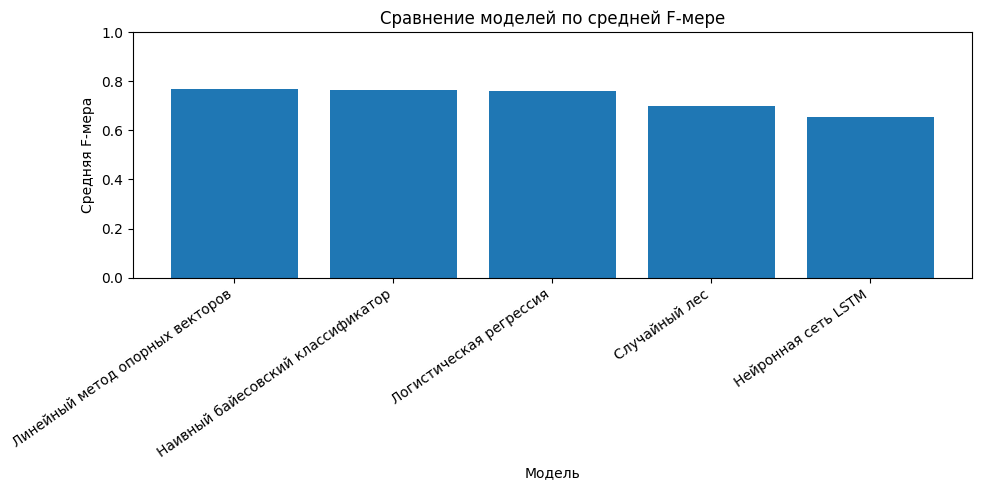

In [40]:
# Строим график сравнения моделей по средней F-мере.
# F-мера выбрана для визуализации, потому что учитывает ошибки
# с разной стороны: ложные срабатывания и пропуски класса.

plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison_df["Модель"],
    model_comparison_df["F-мера средняя"]
)

plt.title("Сравнение моделей по средней F-мере")
plt.xlabel("Модель")
plt.ylabel("Средняя F-мера")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

comparison_plot_path = reports_dir / "stage6_model_comparison_f1.png"

plt.savefig(
    comparison_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

<Figure size 600x500 with 0 Axes>

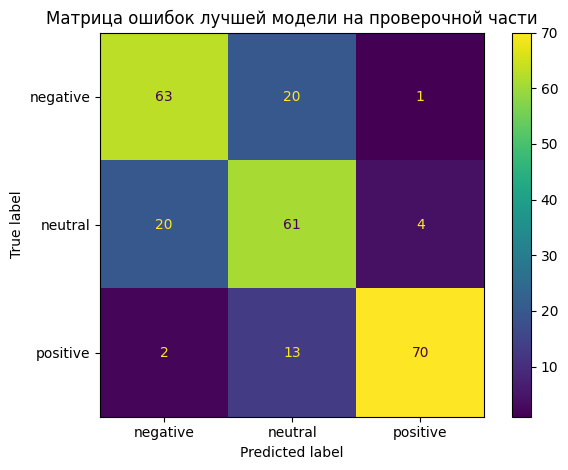

In [41]:
# Определяем лучшую модель по средней F-мере на проверочной части.
# Если лучшей оказалась классическая модель, ответы берутся из сохраненной
# в памяти цепочки обработки текста и классификатора.
# Если лучшей оказалась нейронная сеть, ответы берутся из deep_model.

best_model_candidate_name = model_comparison_df.loc[
    0,
    "Модель"
]

if best_model_candidate_name == "Нейронная сеть LSTM":
    best_valid_pred = deep_valid_pred
else:
    best_model_candidate = trained_classical_models[best_model_candidate_name]
    best_valid_pred = best_model_candidate.predict(X_valid)


# Строим матрицу ошибок для лучшей модели на проверочной части.
# Строки соответствуют настоящим классам, столбцы соответствуют ответам модели.

best_confusion_matrix = confusion_matrix(
    y_valid,
    best_valid_pred,
    labels=class_names
)

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=best_confusion_matrix,
    display_labels=class_names
).plot(
    values_format="d"
)

plt.title("Матрица ошибок лучшей модели на проверочной части")
plt.tight_layout()

confusion_matrix_path = reports_dir / "stage6_best_model_confusion_matrix.png"

plt.savefig(
    confusion_matrix_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

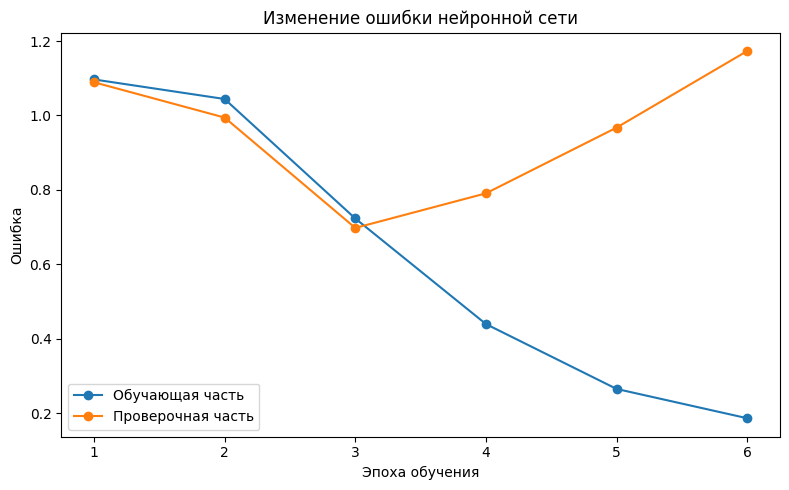

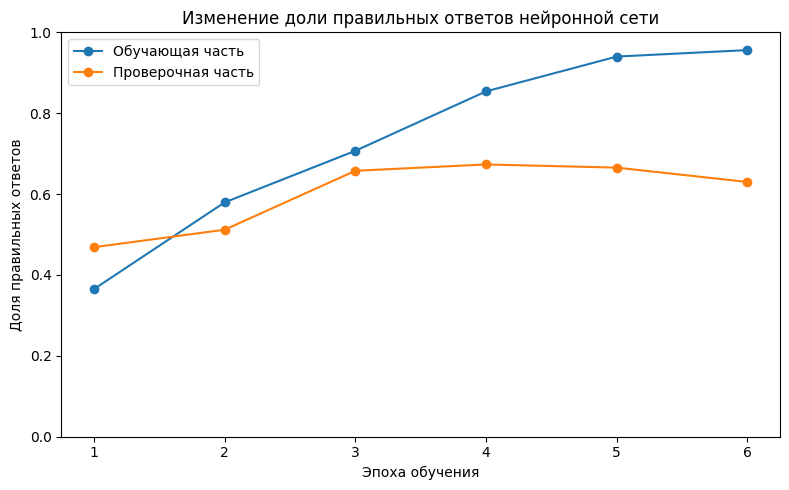

In [42]:
# Строим графики обучения нейронной сети.
# Первый график показывает изменение ошибки на обучающей и проверочной частях.
# Второй график показывает изменение доли правильных ответов.

history_df = pd.DataFrame(deep_history.history)

history_path = reports_dir / "stage6_deep_learning_history.csv"

history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig"
)


plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index + 1,
    history_df["loss"],
    marker="o",
    label="Обучающая часть"
)

plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    marker="o",
    label="Проверочная часть"
)

plt.title("Изменение ошибки нейронной сети")
plt.xlabel("Эпоха обучения")
plt.ylabel("Ошибка")
plt.legend()
plt.tight_layout()

deep_loss_plot_path = reports_dir / "stage6_deep_learning_loss.png"

plt.savefig(
    deep_loss_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index + 1,
    history_df["accuracy"],
    marker="o",
    label="Обучающая часть"
)

plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    marker="o",
    label="Проверочная часть"
)

plt.title("Изменение доли правильных ответов нейронной сети")
plt.xlabel("Эпоха обучения")
plt.ylabel("Доля правильных ответов")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

deep_accuracy_plot_path = reports_dir / "stage6_deep_learning_accuracy.png"

plt.savefig(
    deep_accuracy_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

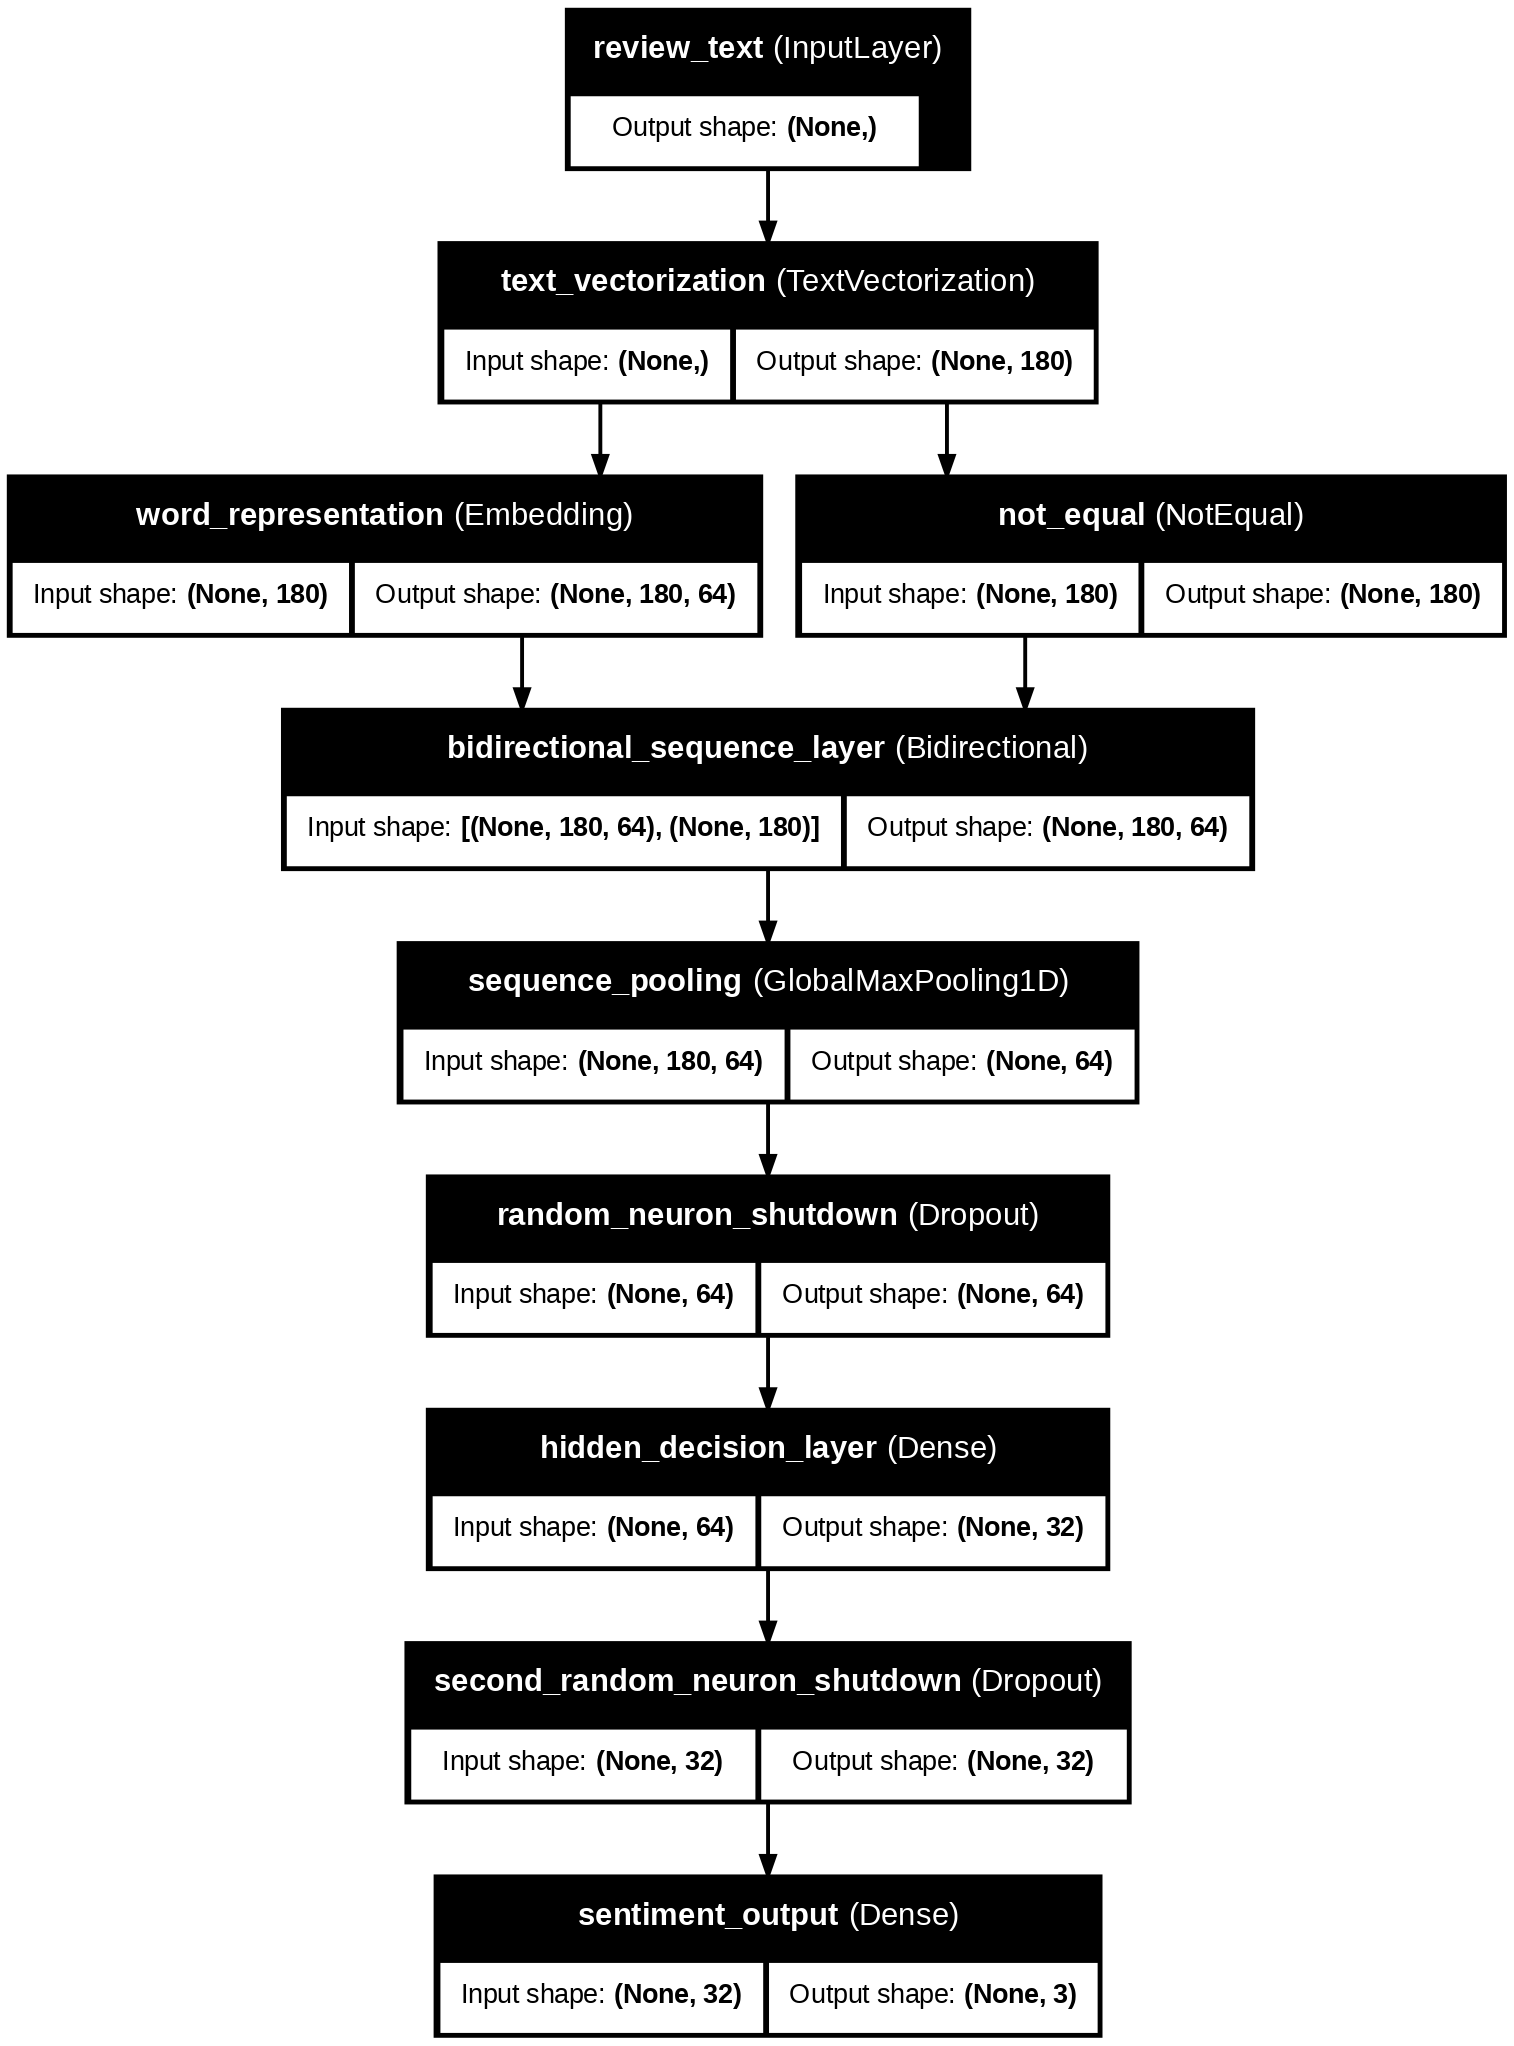

In [43]:
# Создаем графическую схему нейронной сети.
# Если средство построения схемы недоступно в текущей среде, создается
# простая схема слоев средствами matplotlib.

deep_architecture_path = reports_dir / "stage6_deep_model_architecture.png"

try:
    tf.keras.utils.plot_model(
        deep_model,
        to_file=str(deep_architecture_path),
        show_shapes=True,
        show_layer_names=True,
        dpi=140
    )
except Exception:
    layer_names = [
        "Текст отзыва",
        "Разделение текста на слова",
        "Числовые представления слов",
        "Двунаправленный слой LSTM",
        "Объединение признаков последовательности",
        "Скрытый решающий слой",
        "Выходной слой тональности",
    ]

    plt.figure(figsize=(8, 9))

    for index, layer_name in enumerate(layer_names):
        y_position = len(layer_names) - index

        plt.text(
            0.5,
            y_position,
            layer_name,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.4",
                fill=False
            )
        )

        if index < len(layer_names) - 1:
            plt.annotate(
                "",
                xy=(0.5, y_position - 0.35),
                xytext=(0.5, y_position - 0.75),
                arrowprops=dict(arrowstyle="->")
            )

    plt.axis("off")
    plt.title("Схема нейронной сети")
    plt.tight_layout()

    plt.savefig(
        deep_architecture_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()


# Отображаем схему нейронной сети в ноутбуке.

from IPython.display import Image, display

display(
    Image(
        filename=str(deep_architecture_path)
    )
)

In [44]:
# Формируем служебную сводку этапа.
# Пути к отчетным материалам понадобятся при описании эксперимента.

stage6_artifacts = pd.DataFrame(
    {
        "Материал": [
            "Таблица сравнения моделей",
            "Таблица качества по классам",
            "График сравнения моделей",
            "Матрица ошибок лучшей модели",
            "История обучения нейронной сети",
            "График ошибки нейронной сети",
            "График доли правильных ответов нейронной сети",
            "Схема нейронной сети",
            "Лучший кандидат по проверочной части",
        ],
        "Значение": [
            str(model_comparison_path),
            str(class_report_path),
            str(comparison_plot_path),
            str(confusion_matrix_path),
            str(history_path),
            str(deep_loss_plot_path),
            str(deep_accuracy_plot_path),
            str(deep_architecture_path),
            best_model_candidate_name,
        ],
    }
)

stage6_artifacts

,Материал,Значение
0,Таблица сравнения моделей,/content/irbis_feedback_experiment/reports/sta...
1,Таблица качества по классам,/content/irbis_feedback_experiment/reports/sta...
2,График сравнения моделей,/content/irbis_feedback_experiment/reports/sta...
3,Матрица ошибок лучшей модели,/content/irbis_feedback_experiment/reports/sta...
4,История обучения нейронной сети,/content/irbis_feedback_experiment/reports/sta...
5,График ошибки нейронной сети,/content/irbis_feedback_experiment/reports/sta...
6,График доли правильных ответов нейронной сети,/content/irbis_feedback_experiment/reports/sta...
7,Схема нейронной сети,/content/irbis_feedback_experiment/reports/sta...
8,Лучший кандидат по проверочной части,Линейный метод опорных векторов


Лучший результат на проверочной части показал линейный метод опорных векторов, для которого средняя F-мера составила 0,7674, доля правильных ответов — 0,7638. Наивный байесовский классификатор и логистическая регрессия дали близкое качество, что подтверждает устойчивость признакового подхода на основе частот слов. Случайный лес уступил линейным моделям, а нейронная сеть показала признаки переобучения – ошибка на обучающей части снижалась, проверочная ошибка после третьей эпохи начала расти.

Матрица ошибок лучшей модели указывает на основную трудность эксперимента из-за того, что отрицательные и нейтральные отзывы частично смешиваются между собой. Положительный класс распознается лучше, поскольку в текстах с высокой оценкой чаще встречаются явно выраженные слова благодарности и одобрения. Для улучшения итогового варианта логично подобрать параметры лучшей линейной модели. LinearSVC подходит для разреженных признаков, которые формирует частотное представление текста, а многоклассовая классификация в этом методе строится по схеме «один класс против остальных». Подбор параметров выполняется через GridSearchCV, который перебирает заданные сочетания параметров и выбирает лучший вариант по проверке на нескольких разбиениях обучающей части.

# 7. Подбор параметров и итоговая проверка лучшей модели

На предыдущем этапе лучшим кандидатом стал линейный метод опорных векторов. Для повышения качества подбираются параметры преобразования текста и параметр строгости разделяющей границы модели. Проверка выполняется на нескольких разбиениях обучающей части, а контрольная часть остается закрытой до итоговой оценки.

После подбора параметров модель проверяется на контрольной части, которая ранее не участвовала в обучении и выборе настроек. По результатам строятся таблицы качества, матрица ошибок, график сравнения базовой и улучшенной модели, таблица наиболее значимых текстовых признаков и схема итоговой цепочки обработки текста.

In [45]:
# Подключаем средства для подбора параметров и итоговой оценки.
# GridSearchCV перебирает заданные сочетания параметров модели.
# classification_report рассчитывает качество отдельно по каждому классу.
# confusion_matrix строит таблицу совпадений настоящих и предсказанных классов.

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time


# Объединяем обучающую и проверочную части.
# На предыдущем этапе проверочная часть помогла выбрать семейство модели.
# Теперь обе части можно использовать для подбора параметров внутри обучающего материала.
# Контрольная часть X_test и y_test остается отдельной для итоговой проверки.

X_tuning = pd.concat(
    [
        X_train.reset_index(drop=True),
        X_valid.reset_index(drop=True)
    ],
    axis=0
).reset_index(drop=True)

y_tuning = pd.concat(
    [
        y_train.reset_index(drop=True),
        y_valid.reset_index(drop=True)
    ],
    axis=0
).reset_index(drop=True)


# Формируем сводку по данным для подбора параметров и итоговой проверки.

stage7_split_overview = pd.DataFrame(
    {
        "Часть данных": [
            "Материал для подбора параметров",
            "Контрольная часть для итоговой проверки",
        ],
        "Количество отзывов": [
            len(X_tuning),
            len(X_test),
        ],
    }
)

stage7_split_overview

,Часть данных,Количество отзывов
0,Материал для подбора параметров,1438
1,Контрольная часть для итоговой проверки,254


In [46]:
# Проверяем распределение классов после объединения обучающей и проверочной частей.
# Равномерность распределения нужна для устойчивого подбора параметров.

stage7_class_distribution = pd.concat(
    [
        y_tuning.value_counts().sort_index().rename("Материал для подбора параметров"),
        y_test.value_counts().sort_index().rename("Контрольная часть"),
    ],
    axis=1
).fillna(0).astype(int)

stage7_class_distribution

,Материал для подбора параметров,Контрольная часть
sentiment,,
negative,479,85
neutral,480,84
positive,479,85


In [47]:
# Создаем базовый вариант лучшей модели.
# Базовый вариант повторяет настройки линейного метода опорных векторов
# с предыдущего этапа и нужен для честного сравнения с улучшенным вариантом.

baseline_pipeline = Pipeline(
    steps=[
        (
            "text_features",
            TfidfVectorizer(
                max_features=8000,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=6000
            )
        ),
    ]
)


# Обучаем базовый вариант на материале для подбора параметров.
# Контрольная часть в обучении не участвует.

baseline_start_time = time.time()

baseline_pipeline.fit(
    X_tuning,
    y_tuning
)

baseline_train_seconds = round(
    time.time() - baseline_start_time,
    4
)


# Получаем ответы базового варианта на контрольной части.

baseline_test_pred = baseline_pipeline.predict(
    X_test
)

In [48]:
# Создаем цепочку для подбора параметров.
# В цепочку входят преобразование текста и линейный классификатор.
# Классификатор — модель, которая относит отзыв к одному из классов тональности.

search_pipeline = Pipeline(
    steps=[
        (
            "text_features",
            TfidfVectorizer()
        ),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=8000
            )
        ),
    ]
)


# Задаем набор параметров для перебора.
# max_features ограничивает число текстовых признаков.
# ngram_range задает учет отдельных слов или отдельных слов вместе с парами соседних слов.
# min_df убирает слишком редкие слова.
# sublinear_tf сглаживает влияние очень частых слов.
# C управляет строгостью разделения классов: меньшие значения сильнее ограничивают модель,
# большие значения дают модели больше свободы при разделении классов.

parameter_grid = {
    "text_features__max_features": [5000, 8000, 12000],
    "text_features__ngram_range": [(1, 1), (1, 2)],
    "text_features__min_df": [1, 2, 3],
    "text_features__sublinear_tf": [True],
    "classifier__C": [0.3, 0.7, 1.0, 1.5, 2.5],
}


# Создаем средство подбора параметров.
# cv=3 означает проверку каждого сочетания параметров на трех разбиениях.
# scoring="f1_macro" выбирает среднюю F-меру по классам как главный показатель.
# n_jobs=-1 задействует доступные вычислительные ядра.

parameter_search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    refit=True,
    verbose=1
)


# Запускаем подбор параметров на объединенной обучающей части.

search_start_time = time.time()

parameter_search.fit(
    X_tuning,
    y_tuning
)

search_train_seconds = round(
    time.time() - search_start_time,
    4
)


# Получаем улучшенную модель с лучшими найденными параметрами.

tuned_pipeline = parameter_search.best_estimator_

Fitting 3 folds for each of 90 candidates, totalling 270 fits


In [49]:
# Применяем улучшенную модель к контрольной части.
# Контрольная часть не участвовала в обучении и подборе параметров.

tuned_test_pred = tuned_pipeline.predict(
    X_test
)


# Создаем функцию для расчета итоговых показателей качества.
# Доля правильных ответов показывает общий процент верных ответов.
# Точность средняя, полнота средняя и F-мера средняя рассчитываются как средние значения по классам.

def evaluate_final_model(model_name, y_true, y_pred, train_seconds):
    return {
        "Модель": model_name,
        "Доля правильных ответов": accuracy_score(
            y_true,
            y_pred
        ),
        "Точность средняя": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Полнота средняя": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F-мера средняя": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Время обучения и подбора, секунд": train_seconds,
    }


# Формируем таблицу сравнения базовой и улучшенной модели.

final_test_comparison_df = pd.DataFrame(
    [
        evaluate_final_model(
            model_name="Линейный метод опорных векторов до подбора параметров",
            y_true=y_test,
            y_pred=baseline_test_pred,
            train_seconds=baseline_train_seconds
        ),
        evaluate_final_model(
            model_name="Линейный метод опорных векторов после подбора параметров",
            y_true=y_test,
            y_pred=tuned_test_pred,
            train_seconds=search_train_seconds
        ),
    ]
)

quality_columns = [
    "Доля правильных ответов",
    "Точность средняя",
    "Полнота средняя",
    "F-мера средняя",
    "Время обучения и подбора, секунд",
]

for column_name in quality_columns:
    final_test_comparison_df[column_name] = final_test_comparison_df[column_name].round(4)


# Сохраняем таблицу для отчета.

stage7_final_comparison_path = reports_dir / "stage7_final_test_comparison.csv"

final_test_comparison_df.to_csv(
    stage7_final_comparison_path,
    index=False,
    encoding="utf-8-sig"
)

final_test_comparison_df

,Модель,Доля правильных ответов,Точность средняя,Полнота средняя,F-мера средняя,"Время обучения и подбора, секунд"
0,Линейный метод опорных векторов до подбора пар...,0.7087,0.7052,0.7080,0.7058,0.4278
1,Линейный метод опорных векторов после подбора ...,0.7165,0.7124,0.7159,0.7132,55.7669


In [50]:
# Показываем лучшие найденные параметры.
# Таблица понадобится для описания улучшенного варианта модели.

best_parameters_df = pd.DataFrame(
    {
        "Параметр": list(parameter_search.best_params_.keys()),
        "Значение": [str(value) for value in parameter_search.best_params_.values()],
    }
)

best_parameters_df = pd.concat(
    [
        pd.DataFrame(
            {
                "Параметр": ["Лучшее среднее значение F-меры при подборе"],
                "Значение": [round(parameter_search.best_score_, 4)],
            }
        ),
        best_parameters_df
    ],
    axis=0
).reset_index(drop=True)


# Сохраняем параметры для отчетной части.

stage7_best_parameters_path = reports_dir / "stage7_best_parameters.csv"

best_parameters_df.to_csv(
    stage7_best_parameters_path,
    index=False,
    encoding="utf-8-sig"
)

best_parameters_df

,Параметр,Значение
0,Лучшее среднее значение F-меры при подборе,0.7245
1,classifier__C,0.7
2,text_features__max_features,8000
3,text_features__min_df,1
4,text_features__ngram_range,"(1, 2)"
5,text_features__sublinear_tf,True


In [51]:
# Формируем подробный отчет по классам для улучшенной модели.
# Отчет показывает качество распознавания отрицательных, нейтральных
# и положительных отзывов на контрольной части.

final_report_dict = classification_report(
    y_test,
    tuned_test_pred,
    labels=class_names,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

final_class_report_rows = []

for class_name in class_names:
    final_class_report_rows.append(
        {
            "Класс тональности": class_name,
            "Точность": final_report_dict[class_name]["precision"],
            "Полнота": final_report_dict[class_name]["recall"],
            "F-мера": final_report_dict[class_name]["f1-score"],
            "Количество отзывов": final_report_dict[class_name]["support"],
        }
    )

final_class_report_df = pd.DataFrame(
    final_class_report_rows
)

for column_name in ["Точность", "Полнота", "F-мера"]:
    final_class_report_df[column_name] = final_class_report_df[column_name].round(4)


# Сохраняем отчет по классам.

stage7_final_class_report_path = reports_dir / "stage7_final_class_report.csv"

final_class_report_df.to_csv(
    stage7_final_class_report_path,
    index=False,
    encoding="utf-8-sig"
)

final_class_report_df

,Класс тональности,Точность,Полнота,F-мера,Количество отзывов
0,negative,0.6923,0.7412,0.7159,85.0
1,neutral,0.6267,0.5595,0.5912,84.0
2,positive,0.8182,0.8471,0.8324,85.0


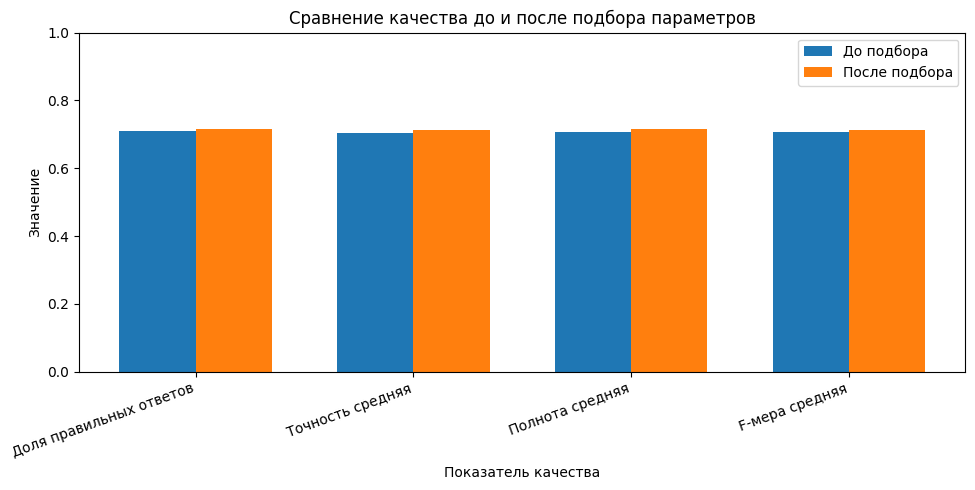

In [52]:
# Строим график сравнения базовой и улучшенной модели.
# На графике сопоставляются четыре показателя качества на контрольной части.

plot_metrics = [
    "Доля правильных ответов",
    "Точность средняя",
    "Полнота средняя",
    "F-мера средняя",
]

plot_df = final_test_comparison_df[
    ["Модель"] + plot_metrics
].copy()

plot_df["Модель"] = plot_df["Модель"].replace(
    {
        "Линейный метод опорных векторов до подбора параметров": "До подбора",
        "Линейный метод опорных векторов после подбора параметров": "После подбора",
    }
)

x_positions = np.arange(
    len(plot_metrics)
)

bar_width = 0.35

plt.figure(figsize=(10, 5))

for model_index, model_name in enumerate(plot_df["Модель"]):
    values = plot_df.loc[
        plot_df["Модель"] == model_name,
        plot_metrics
    ].values.flatten()

    plt.bar(
        x_positions + model_index * bar_width,
        values,
        width=bar_width,
        label=model_name
    )

plt.title("Сравнение качества до и после подбора параметров")
plt.xlabel("Показатель качества")
plt.ylabel("Значение")
plt.ylim(0, 1)
plt.xticks(
    x_positions + bar_width / 2,
    plot_metrics,
    rotation=20,
    ha="right"
)
plt.legend()
plt.tight_layout()

stage7_metrics_plot_path = reports_dir / "stage7_metrics_before_after.png"

plt.savefig(
    stage7_metrics_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

<Figure size 600x500 with 0 Axes>

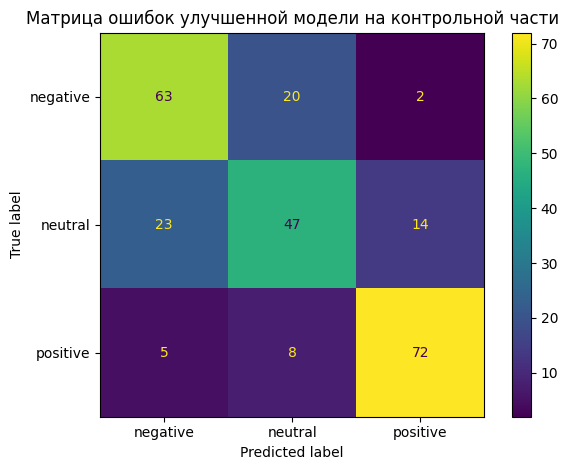

In [53]:
# Строим матрицу ошибок улучшенной модели на контрольной части.
# Строки соответствуют настоящим классам, столбцы соответствуют ответам модели.

final_confusion_matrix = confusion_matrix(
    y_test,
    tuned_test_pred,
    labels=class_names
)

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=class_names
).plot(
    values_format="d"
)

plt.title("Матрица ошибок улучшенной модели на контрольной части")
plt.tight_layout()

stage7_confusion_matrix_path = reports_dir / "stage7_final_confusion_matrix.png"

plt.savefig(
    stage7_confusion_matrix_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

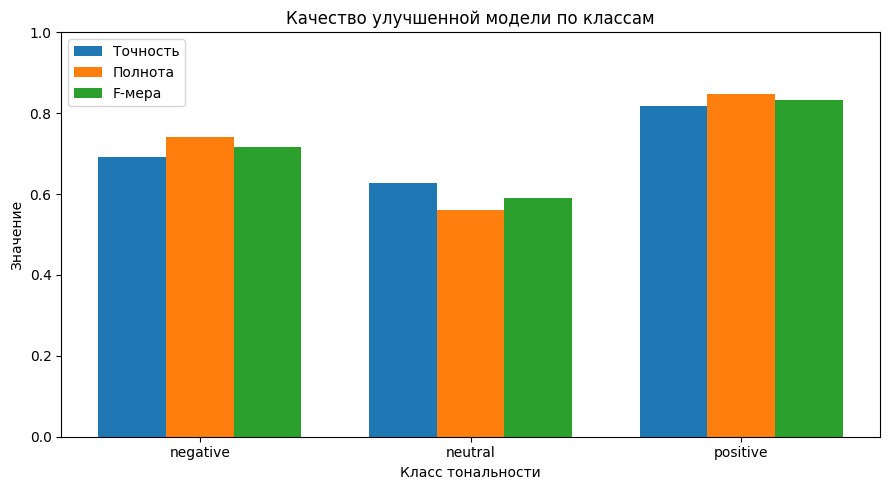

In [54]:
# Строим график качества улучшенной модели по классам.
# График помогает увидеть, какой класс распознается устойчивее,
# а какой требует большего числа обучающих примеров.

class_metric_names = [
    "Точность",
    "Полнота",
    "F-мера",
]

x_positions = np.arange(
    len(final_class_report_df["Класс тональности"])
)

bar_width = 0.25

plt.figure(figsize=(9, 5))

for metric_index, metric_name in enumerate(class_metric_names):
    plt.bar(
        x_positions + metric_index * bar_width,
        final_class_report_df[metric_name],
        width=bar_width,
        label=metric_name
    )

plt.title("Качество улучшенной модели по классам")
plt.xlabel("Класс тональности")
plt.ylabel("Значение")
plt.ylim(0, 1)
plt.xticks(
    x_positions + bar_width,
    final_class_report_df["Класс тональности"]
)
plt.legend()
plt.tight_layout()

stage7_class_metrics_plot_path = reports_dir / "stage7_class_metrics.png"

plt.savefig(
    stage7_class_metrics_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [55]:
# Извлекаем наиболее значимые текстовые признаки улучшенной модели.
# Для линейной модели коэффициенты показывают, какие слова и выражения
# сильнее связаны с каждым классом тональности.

final_vectorizer = tuned_pipeline.named_steps["text_features"]
final_classifier = tuned_pipeline.named_steps["classifier"]

feature_names = final_vectorizer.get_feature_names_out()
classifier_classes = final_classifier.classes_

top_features_rows = []

top_feature_count = 15

for class_index, class_name in enumerate(classifier_classes):
    class_coefficients = final_classifier.coef_[class_index]

    top_indexes = np.argsort(
        class_coefficients
    )[-top_feature_count:][::-1]

    for rank_index, feature_index in enumerate(top_indexes, start=1):
        top_features_rows.append(
            {
                "Класс тональности": class_name,
                "Место": rank_index,
                "Текстовый признак": feature_names[feature_index],
                "Коэффициент": class_coefficients[feature_index],
            }
        )

top_features_df = pd.DataFrame(
    top_features_rows
)

top_features_df["Коэффициент"] = top_features_df["Коэффициент"].round(4)


# Сохраняем таблицу значимых признаков.

stage7_top_features_path = reports_dir / "stage7_top_text_features.csv"

top_features_df.to_csv(
    stage7_top_features_path,
    index=False,
    encoding="utf-8-sig"
)

top_features_df

,Класс тональности,Место,Текстовый признак,Коэффициент
0,negative,1,не рекомендую,1.5502
1,negative,2,не,1.4113
2,negative,3,отношение,1.1322
3,negative,4,им,1.1065
4,negative,5,что,1.0689
5,negative,6,ужасное,1.0271
6,negative,7,чтобы,0.9982
7,negative,8,ничего,0.9760
8,negative,9,эту,0.9606
9,negative,10,после,0.9408


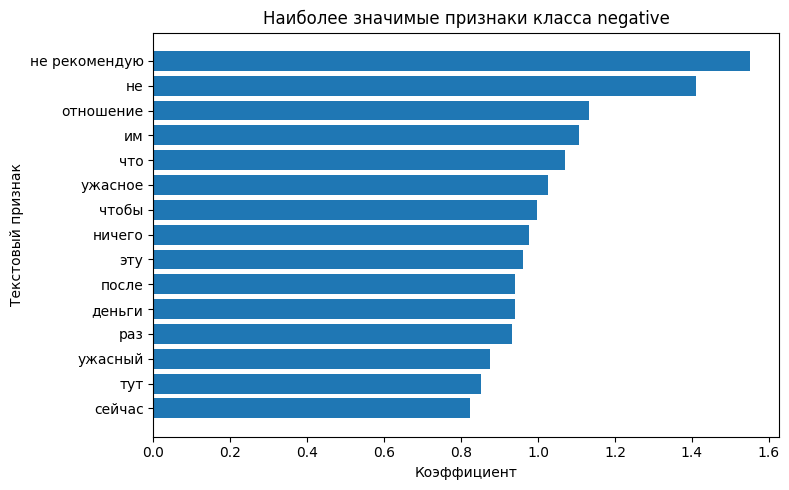

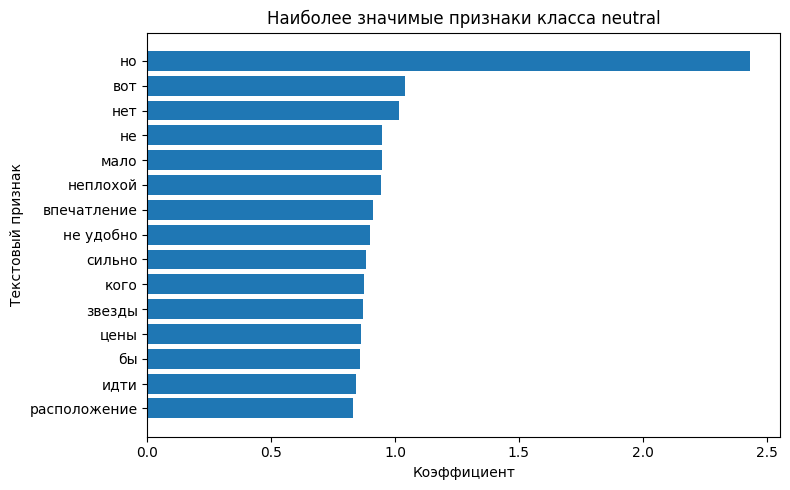

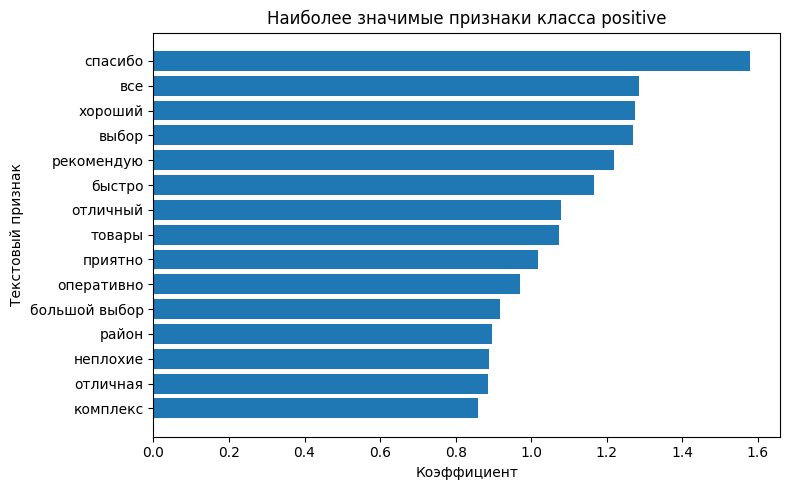

In [56]:
# Строим графики наиболее значимых признаков по каждому классу.
# Каждый рисунок показывает слова и короткие выражения,
# которые сильнее всего связаны с выбранным классом тональности.

top_feature_plot_paths = []

for class_name in classifier_classes:
    class_features = top_features_df[
        top_features_df["Класс тональности"] == class_name
    ].sort_values(
        by="Коэффициент",
        ascending=True
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        class_features["Текстовый признак"],
        class_features["Коэффициент"]
    )

    plt.title(f"Наиболее значимые признаки класса {class_name}")
    plt.xlabel("Коэффициент")
    plt.ylabel("Текстовый признак")
    plt.tight_layout()

    feature_plot_path = reports_dir / f"stage7_top_features_{class_name}.png"

    plt.savefig(
        feature_plot_path,
        dpi=200,
        bbox_inches="tight"
    )

    top_feature_plot_paths.append(
        str(feature_plot_path)
    )

    plt.show()

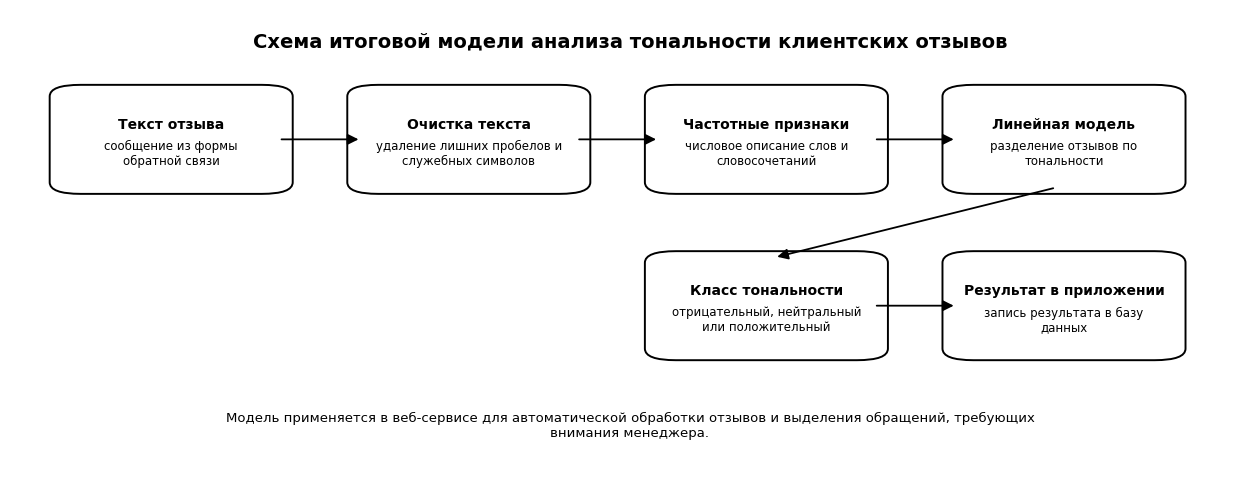

In [59]:
# Создаем аккуратную схему итоговой модели.
# Схема показывает путь клиентского отзыва от ввода в веб-форму
# до сохранения результата анализа в базе данных приложения.

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import textwrap


# Задаем путь для сохранения рисунка.
# Новый файл заменит предыдущий вариант схемы.

model_scheme_path = reports_dir / "stage7_final_model_scheme.png"


# Создаем рисунок с горизонтальной ориентацией.
# Размер подобран так, чтобы подписи не накладывались друг на друга.

fig, ax = plt.subplots(figsize=(16, 6))


# Отключаем координатные оси, поскольку строится схема процесса.

ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)


# Задаем функцию переноса длинного текста.
# Перенос ограничивает ширину подписи внутри блока.

def wrap_text(text_value, width=24):
    return "\n".join(
        textwrap.wrap(
            text_value,
            width=width,
            break_long_words=False
        )
    )


# Описываем блоки схемы.
# Каждый блок содержит короткое название операции и уточнение результата.

scheme_blocks = {
    "input": {
        "title": "Текст отзыва",
        "description": "сообщение из формы обратной связи",
        "x": 0.05,
        "y": 0.62,
        "width": 0.16,
        "height": 0.20,
    },
    "cleaning": {
        "title": "Очистка текста",
        "description": "удаление лишних пробелов и служебных символов",
        "x": 0.29,
        "y": 0.62,
        "width": 0.16,
        "height": 0.20,
    },
    "features": {
        "title": "Частотные признаки",
        "description": "числовое описание слов и словосочетаний",
        "x": 0.53,
        "y": 0.62,
        "width": 0.16,
        "height": 0.20,
    },
    "model": {
        "title": "Линейная модель",
        "description": "разделение отзывов по тональности",
        "x": 0.77,
        "y": 0.62,
        "width": 0.16,
        "height": 0.20,
    },
    "class": {
        "title": "Класс тональности",
        "description": "отрицательный, нейтральный или положительный",
        "x": 0.53,
        "y": 0.26,
        "width": 0.16,
        "height": 0.20,
    },
    "database": {
        "title": "Результат в приложении",
        "description": "запись результата в базу данных",
        "x": 0.77,
        "y": 0.26,
        "width": 0.16,
        "height": 0.20,
    },
}


# Задаем оформление блоков.
# Белый фон и черная рамка подходят для вставки рисунка в отчет.

box_style = "round,pad=0.018,rounding_size=0.025"


# Рисуем блоки схемы.

for block in scheme_blocks.values():
    block_patch = FancyBboxPatch(
        (block["x"], block["y"]),
        block["width"],
        block["height"],
        boxstyle=box_style,
        linewidth=1.4,
        edgecolor="black",
        facecolor="white"
    )

    ax.add_patch(block_patch)

    ax.text(
        block["x"] + block["width"] / 2,
        block["y"] + block["height"] * 0.66,
        wrap_text(block["title"], width=22),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        block["x"] + block["width"] / 2,
        block["y"] + block["height"] * 0.34,
        wrap_text(block["description"], width=26),
        ha="center",
        va="center",
        fontsize=8.5
    )


# Создаем вспомогательные функции для расчета точек соединения.
# Координаты берутся от границ блоков, поэтому стрелки не проходят через текст.

def right_center(block):
    return (
        block["x"] + block["width"],
        block["y"] + block["height"] / 2
    )


def left_center(block):
    return (
        block["x"],
        block["y"] + block["height"] / 2
    )


def bottom_center(block):
    return (
        block["x"] + block["width"] / 2,
        block["y"]
    )


def top_center(block):
    return (
        block["x"] + block["width"] / 2,
        block["y"] + block["height"]
    )


# Создаем функцию добавления стрелки.
# Стрелка показывает направление передачи результата между операциями.

def add_arrow(start_point, end_point):
    arrow_patch = FancyArrowPatch(
        start_point,
        end_point,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.3,
        color="black",
        shrinkA=8,
        shrinkB=8
    )

    ax.add_patch(arrow_patch)


# Добавляем стрелки верхнего ряда.

add_arrow(
    right_center(scheme_blocks["input"]),
    left_center(scheme_blocks["cleaning"])
)

add_arrow(
    right_center(scheme_blocks["cleaning"]),
    left_center(scheme_blocks["features"])
)

add_arrow(
    right_center(scheme_blocks["features"]),
    left_center(scheme_blocks["model"])
)


# Добавляем переход от модели к классу тональности.
# Стрелка идет вниз и не пересекает другие элементы схемы.

add_arrow(
    bottom_center(scheme_blocks["model"]),
    top_center(scheme_blocks["class"])
)


# Добавляем переход от класса тональности к записи результата.

add_arrow(
    right_center(scheme_blocks["class"]),
    left_center(scheme_blocks["database"])
)


# Добавляем заголовок рисунка.

ax.text(
    0.5,
    0.93,
    "Схема итоговой модели анализа тональности клиентских отзывов",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)


# Добавляем краткое пояснение под схемой.

ax.text(
    0.5,
    0.10,
    wrap_text(
        "Модель применяется в веб-сервисе для автоматической обработки отзывов и выделения обращений, требующих внимания менеджера.",
        width=110
    ),
    ha="center",
    va="center",
    fontsize=9.5
)


# Сохраняем рисунок с небольшими полями.
# Параметр bbox_inches ограничивает файл областью содержимого.

plt.savefig(
    model_scheme_path,
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.20
)

plt.show()

In [60]:
# Формируем перечень материалов, созданных на этапе подбора параметров.
# Таблица помогает быстро проверить наличие отчетных файлов.

stage7_artifacts = pd.DataFrame(
    {
        "Материал": [
            "Сравнение базовой и улучшенной модели",
            "Лучшие параметры",
            "Отчет по классам на контрольной части",
            "График качества до и после подбора",
            "Матрица ошибок на контрольной части",
            "График качества по классам",
            "Таблица значимых текстовых признаков",
            "Схема итоговой модели",
            "Графики значимых признаков",
        ],
        "Значение": [
            str(stage7_final_comparison_path),
            str(stage7_best_parameters_path),
            str(stage7_final_class_report_path),
            str(stage7_metrics_plot_path),
            str(stage7_confusion_matrix_path),
            str(stage7_class_metrics_plot_path),
            str(stage7_top_features_path),
            str(model_scheme_path),
            "; ".join(top_feature_plot_paths),
        ],
    }
)

stage7_artifacts

,Материал,Значение
0,Сравнение базовой и улучшенной модели,/content/irbis_feedback_experiment/reports/sta...
1,Лучшие параметры,/content/irbis_feedback_experiment/reports/sta...
2,Отчет по классам на контрольной части,/content/irbis_feedback_experiment/reports/sta...
3,График качества до и после подбора,/content/irbis_feedback_experiment/reports/sta...
4,Матрица ошибок на контрольной части,/content/irbis_feedback_experiment/reports/sta...
5,График качества по классам,/content/irbis_feedback_experiment/reports/sta...
6,Таблица значимых текстовых признаков,/content/irbis_feedback_experiment/reports/sta...
7,Схема итоговой модели,/content/irbis_feedback_experiment/reports/sta...
8,Графики значимых признаков,/content/irbis_feedback_experiment/reports/sta...


Подбор параметров дал умеренное улучшение: средняя F-мера на контрольной части выросла с 0,7058 до 0,7132, доля правильных ответов — с 0,7087 до 0,7165. Прирост небольшой, но устойчивый по всем основным метрикам, поэтому улучшенную модель можно выбрать как итоговую.

Слабое место остается прежним: нейтральный класс распознается хуже отрицательного и положительного. Матрица ошибок подтверждает, что часть нейтральных отзывов переходит в отрицательный или положительный класс, поскольку отзывы с оценкой 3 часто содержат смешанные формулировки. Для пользовательского приложения результат приемлем, поскольку модель уверенно выделяет положительные и отрицательные обращения, а нейтральные сообщения сохраняются как отдельная промежуточная категория.

На завершающем этапе сохраняются только необходимые артефакты для Flask-приложения.

# 8. Сохранение артефактов для пользовательского приложения

На завершающем этапе сохраняется итоговая модель, сведения о качестве, словарь аспектов клиентских обращений и файл зависимостей. Модель переобучается на полном сбалансированном наборе с параметрами, выбранными на предыдущем этапе. Контрольная проверка уже выполнена, поэтому полный набор можно использовать для подготовки версии, предназначенной для веб-приложения.

В пользовательское приложение передается единая цепочка обработки текста: очищенный отзыв преобразуется в числовые признаки, после чего классификатор определяет тональность сообщения. Дополнительный словарь аспектов нужен для простого выделения темы обращения: сроки, стоимость, документы, коммуникация, качество работ или объект строительства.

In [61]:
# Подключаем библиотеки для сохранения модели и служебных файлов.
# joblib сохраняет обученную модель в файл.
# json сохраняет сведения о модели и словари в текстовом формате.
# platform помогает зафиксировать версию языка Python.
# sklearn хранит номер версии библиотеки машинного обучения.

import json
import platform
import joblib
import sklearn


# Задаем итоговые пути к артефактам пользовательского приложения.
# В приложение переносится только модель, сведения о модели, словарь аспектов
# и файл зависимостей.

final_model_path = models_dir / "model.joblib"
model_info_path = models_dir / "model_info.json"
aspect_keywords_path = models_dir / "aspect_keywords.json"
requirements_path = PROJECT_DIR / "requirements.txt"


# Получаем лучшие параметры, найденные на предыдущем этапе.
# parameter_search был создан и обучен на этапе подбора параметров.

best_parameters = parameter_search.best_params_

In [62]:
# Создаем итоговую модель с найденными параметрами.
# Модель обучается на полном сбалансированном наборе, сохраненном на этапе 5.
# Такой вариант получает максимум доступных учебных примеров перед переносом
# в пользовательское приложение.

final_pipeline = Pipeline(
    steps=[
        (
            "text_features",
            TfidfVectorizer(
                max_features=best_parameters["text_features__max_features"],
                ngram_range=best_parameters["text_features__ngram_range"],
                min_df=best_parameters["text_features__min_df"],
                sublinear_tf=best_parameters["text_features__sublinear_tf"],
            )
        ),
        (
            "classifier",
            LinearSVC(
                C=best_parameters["classifier__C"],
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=8000
            )
        ),
    ]
)


# Обучаем итоговую модель на полном сбалансированном наборе.
# Используется таблица balanced_reviews_df, полученная после балансировки классов.

final_pipeline.fit(
    balanced_reviews_df["clean_text"],
    balanced_reviews_df["sentiment"]
)


# Сохраняем итоговую модель в один файл.
# Файл model.joblib будет загружаться во Flask-приложении при запуске сервера.

joblib.dump(
    final_pipeline,
    final_model_path
)

['/content/irbis_feedback_experiment/models/model.joblib']

In [63]:
# Создаем словарь аспектов клиентских обращений.
# Словарь работает как простое правило поиска ключевых слов в тексте.
# Он не заменяет модель тональности, а дополняет ее тематической группировкой.

aspect_keywords = {
    "Сроки": [
        "срок",
        "задерж",
        "долго",
        "быстро",
        "оперативно",
        "ожидан",
        "перенесли",
        "не успели",
        "месяц",
        "неделя",
    ],
    "Стоимость": [
        "стоимость",
        "цена",
        "дорого",
        "дешево",
        "смета",
        "расчет",
        "оплата",
        "договор",
        "деньги",
        "переплата",
    ],
    "Документы": [
        "документ",
        "акт",
        "договор",
        "смета",
        "проект",
        "чертеж",
        "отчет",
        "заключение",
        "разрешение",
        "паспорт",
    ],
    "Коммуникация": [
        "менеджер",
        "специалист",
        "ответ",
        "позвонили",
        "связались",
        "общение",
        "консультация",
        "объяснили",
        "поддержка",
        "звонок",
    ],
    "Качество работ": [
        "качество",
        "работа",
        "монтаж",
        "ремонт",
        "ошибка",
        "дефект",
        "замечание",
        "проверка",
        "контроль",
        "переделка",
    ],
    "Объект строительства": [
        "дом",
        "квартира",
        "здание",
        "объект",
        "стройка",
        "жилой комплекс",
        "помещение",
        "офис",
        "фасад",
        "кровля",
    ],
}


# Сохраняем словарь аспектов в текстовый файл.
# ensure_ascii=False сохраняет русские буквы в читаемом виде.

with open(aspect_keywords_path, "w", encoding="utf-8") as file:
    json.dump(
        aspect_keywords,
        file,
        ensure_ascii=False,
        indent=2
    )

In [64]:
# Формируем сведения о модели.
# Файл model_info.json нужен приложению и отчету: в нем указаны классы,
# параметры итоговой модели, метрики контрольной проверки и версии библиотек.

model_info = {
    "model_name": "LinearSVC with TF-IDF features",
    "task": "Классификация тональности клиентских отзывов",
    "classes": class_names,
    "class_description": {
        "negative": "отрицательный отзыв",
        "neutral": "нейтральный отзыв",
        "positive": "положительный отзыв",
    },
    "best_parameters": {
        "classifier_C": best_parameters["classifier__C"],
        "max_features": best_parameters["text_features__max_features"],
        "min_df": best_parameters["text_features__min_df"],
        "ngram_range": list(best_parameters["text_features__ngram_range"]),
        "sublinear_tf": best_parameters["text_features__sublinear_tf"],
    },
    "control_metrics": {
        "accuracy": float(
            final_test_comparison_df.loc[
                final_test_comparison_df["Модель"] == "Линейный метод опорных векторов после подбора параметров",
                "Доля правильных ответов"
            ].iloc[0]
        ),
        "macro_precision": float(
            final_test_comparison_df.loc[
                final_test_comparison_df["Модель"] == "Линейный метод опорных векторов после подбора параметров",
                "Точность средняя"
            ].iloc[0]
        ),
        "macro_recall": float(
            final_test_comparison_df.loc[
                final_test_comparison_df["Модель"] == "Линейный метод опорных векторов после подбора параметров",
                "Полнота средняя"
            ].iloc[0]
        ),
        "macro_f1": float(
            final_test_comparison_df.loc[
                final_test_comparison_df["Модель"] == "Линейный метод опорных векторов после подбора параметров",
                "F-мера средняя"
            ].iloc[0]
        ),
    },
    "training_data": {
        "dataset_file": str(processed_dataset_path),
        "records_count": int(len(balanced_reviews_df)),
        "text_column": "clean_text",
        "target_column": "sentiment",
        "source": "Geo Reviews Dataset 2023 после предметной фильтрации и балансировки",
    },
    "software_versions": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
    },
}


# Сохраняем сведения о модели в файл.

with open(model_info_path, "w", encoding="utf-8") as file:
    json.dump(
        model_info,
        file,
        ensure_ascii=False,
        indent=2
    )

In [65]:
# Создаем файл зависимостей для запуска пользовательского приложения.
# В файл включаются только библиотеки, нужные для загрузки модели,
# работы Flask-приложения и обработки таблиц.

requirements_lines = [
    "Flask>=3.0.0",
    "scikit-learn>=1.4.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "joblib>=1.3.0",
]


# Сохраняем зависимости в requirements.txt.

with open(requirements_path, "w", encoding="utf-8") as file:
    file.write(
        "\n".join(requirements_lines)
    )

In [66]:
# Проверяем загрузку сохраненной модели.
# Проверка имитирует работу пользовательского приложения:
# модель загружается из файла и получает несколько новых клиентских сообщений.

loaded_model = joblib.load(
    final_model_path
)


# Создаем функцию для определения аспекта обращения.
# Если найдено несколько аспектов, выбирается аспект с наибольшим числом совпадений.
# Если совпадений нет, возвращается общее значение.

def detect_aspect(text_value, aspect_dictionary):
    text_value = str(text_value).lower().replace("ё", "е")

    aspect_scores = {}

    for aspect_name, keywords in aspect_dictionary.items():
        matches_count = 0

        for keyword in keywords:
            keyword = keyword.lower().replace("ё", "е")

            if keyword in text_value:
                matches_count += 1

        aspect_scores[aspect_name] = matches_count

    best_aspect = max(
        aspect_scores,
        key=aspect_scores.get
    )

    if aspect_scores[best_aspect] == 0:
        return "Общее обращение"

    return best_aspect


# Создаем примеры сообщений для проверки.
# Примеры отражают возможные обращения клиента строительной компании.

demo_messages = [
    "Спасибо менеджеру за подробную консультацию по строительному контролю, все объяснили быстро и понятно.",
    "Заявку приняли, но ответ по документам пришлось ждать несколько дней.",
    "Не рекомендую обращаться, сроки проверки сорвали, замечания по объекту прислали слишком поздно.",
    "Стоимость работ оказалась выше первоначального расчета, хотелось бы видеть более подробную смету.",
    "Специалист внимательно проверил объект и помог зафиксировать дефекты в акте.",
]


# Получаем тональность и аспект для каждого сообщения.

demo_predictions = loaded_model.predict(
    demo_messages
)

demo_result_rows = []

for message_text, sentiment_label in zip(demo_messages, demo_predictions):
    demo_result_rows.append(
        {
            "Текст обращения": message_text,
            "Тональность": sentiment_label,
            "Аспект": detect_aspect(
                message_text,
                aspect_keywords
            ),
        }
    )


demo_results_df = pd.DataFrame(
    demo_result_rows
)

demo_results_df

,Текст обращения,Тональность,Аспект
0,Спасибо менеджеру за подробную консультацию по...,positive,Коммуникация
1,"Заявку приняли, но ответ по документам пришлос...",neutral,Документы
2,"Не рекомендую обращаться, сроки проверки сорва...",negative,Сроки
3,Стоимость работ оказалась выше первоначального...,negative,Стоимость
4,Специалист внимательно проверил объект и помог...,positive,Документы


In [67]:
# Формируем итоговую таблицу артефактов.
# В таблицу включаются только файлы, нужные для приложения и проверки обучения.

final_artifacts = pd.DataFrame(
    {
        "Артефакт": [
            "Итоговая модель",
            "Сведения о модели",
            "Словарь аспектов",
            "Файл зависимостей",
            "Обучающий набор",
        ],
        "Путь": [
            str(final_model_path),
            str(model_info_path),
            str(aspect_keywords_path),
            str(requirements_path),
            str(processed_dataset_path),
        ],
        "Нужен пользовательскому приложению": [
            "да",
            "да",
            "да",
            "да",
            "нет, нужен для проверки обучения",
        ],
    }
)

final_artifacts

,Артефакт,Путь,Нужен пользовательскому приложению
0,Итоговая модель,/content/irbis_feedback_experiment/models/mode...,да
1,Сведения о модели,/content/irbis_feedback_experiment/models/mode...,да
2,Словарь аспектов,/content/irbis_feedback_experiment/models/aspe...,да
3,Файл зависимостей,/content/irbis_feedback_experiment/requirement...,да
4,Обучающий набор,/content/irbis_feedback_experiment/data/proces...,"нет, нужен для проверки обучения"


In [68]:
# Создаем кнопку для выгрузки только тех файлов, которые нужны пользовательскому приложению.
# В архив включаются итоговая модель, сведения о модели, словарь аспектов и файл зависимостей.
# Обучающий набор и отчетные рисунки в архив не добавляются.

import zipfile
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display
from google.colab import files


# Задаем путь к итоговому архиву.

application_artifacts_zip_path = PROJECT_DIR / "irbis_application_artifacts.zip"


# Описываем файлы, которые нужны пользовательскому приложению.
# Внутренние пути сохраняют будущую структуру Flask-проекта.

application_artifacts = [
    {
        "source_path": final_model_path,
        "archive_path": "models/model.joblib",
    },
    {
        "source_path": model_info_path,
        "archive_path": "models/model_info.json",
    },
    {
        "source_path": aspect_keywords_path,
        "archive_path": "models/aspect_keywords.json",
    },
    {
        "source_path": requirements_path,
        "archive_path": "requirements.txt",
    },
]


# Создаем функцию проверки файлов.
# Если какой-либо файл отсутствует, выполнение останавливается с понятной ошибкой.

def check_application_artifacts(artifacts):
    missing_paths = []

    for artifact in artifacts:
        source_path = Path(artifact["source_path"])

        if not source_path.exists():
            missing_paths.append(str(source_path))

    if missing_paths:
        raise FileNotFoundError(
            "Не найдены обязательные файлы приложения: " + "; ".join(missing_paths)
        )


# Создаем функцию формирования архива.
# Архив перезаписывается при каждом нажатии кнопки.

def build_application_artifacts_archive():
    check_application_artifacts(application_artifacts)

    with zipfile.ZipFile(
        application_artifacts_zip_path,
        mode="w",
        compression=zipfile.ZIP_DEFLATED
    ) as archive:
        for artifact in application_artifacts:
            archive.write(
                filename=Path(artifact["source_path"]),
                arcname=artifact["archive_path"]
            )


# Создаем действие для кнопки.
# После формирования архива запускается стандартная выгрузка файла из Google Colab.

def download_application_artifacts(button):
    build_application_artifacts_archive()
    files.download(str(application_artifacts_zip_path))


# Создаем кнопку выгрузки.

download_button = widgets.Button(
    description="Выгрузить артефакты",
    button_style="primary",
    layout=widgets.Layout(
        width="240px",
        height="42px"
    )
)

download_button.on_click(download_application_artifacts)

display(download_button)

Button(button_style='primary', description='Выгрузить артефакты', layout=Layout(height='42px', width='240px'),…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>